# **Phân tích Dữ liệu Khám phá (Exploratory Data Analysis - EDA)**
**Mục tiêu của Notebook này:** Phân tích, trực quan hoá các đặc trưng của tập dữ liệu BĐS sau khi đã được làm sạch để tìm ra các insight (xu hướng, phân phối giá, ảnh hưởng của khu vực, v.v.)

## **1. Thiết lập môi trường**

In [157]:
import pandas as pd
import numpy as np
import unicodedata
import re
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
from IPython.display import display
import matplotlib.ticker as ticker
import matplotlib.dates as mdates

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [158]:
file_path_clean = '../../data/processed/fulldata_clean_4web.csv'
df_eda = pd.read_csv(file_path_clean)


In [159]:
print(f"Đã đọc xong file: {file_path_clean}")
print(f"DataFrame EDA có shape: {df_eda.shape}")

Đã đọc xong file: ../../data/processed/fulldata_clean_4web.csv
DataFrame EDA có shape: (116863, 19)


Kiểm tra kiểu dữ liệu trước khi phân tích khám phá

In [160]:
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116863 entries, 0 to 116862
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TieuDe         116863 non-null  object 
 1   Nguon          116863 non-null  object 
 2   ThanhPho       83741 non-null   object 
 3   QuanHuyen      116863 non-null  object 
 4   DiaChiFull     116863 non-null  object 
 5   NgayDang       116863 non-null  object 
 6   LoaiBDS        116863 non-null  object 
 7   Gia            116863 non-null  float64
 8   DienTich       116863 non-null  float64
 9   Gia_m2         116863 non-null  float64
 10  MatTien        116863 non-null  float64
 11  DuongVao       116863 non-null  float64
 12  ChieuRong      116863 non-null  float64
 13  ChieuDai       116863 non-null  float64
 14  SoTang         116863 non-null  float64
 15  SoPhongNgu     116863 non-null  float64
 16  SoPhongVeSinh  116863 non-null  float64
 17  SoPhongTam     116863 non-nul

**Lưu ý về kiểu dữ liệu (Data Type):**
- Mặc dù cột `NgayDang` đã được chuẩn hóa về định dạng `datetime` ở bước Preprocessing, nhưng do định dạng lưu trữ file trung gian là `.csv` (chỉ lưu dạng plain text), nên khi `read_csv` tải lên, Pandas sẽ tạm hiểu nó là chuỗi ký tự dạng `object`.
- Do đó ở bước EDA này, để thực hiện các phân tích chuỗi thời gian (Time-series analysis) như tính theo quý, tháng, ta cần thiết lập lại kiểu `datetime` cho cột này.


In [161]:
if 'NgayDang' in df_eda.columns:
    df_eda['NgayDang'] = pd.to_datetime(df_eda['NgayDang'], errors='coerce')

In [162]:
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116863 entries, 0 to 116862
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   TieuDe         116863 non-null  object        
 1   Nguon          116863 non-null  object        
 2   ThanhPho       83741 non-null   object        
 3   QuanHuyen      116863 non-null  object        
 4   DiaChiFull     116863 non-null  object        
 5   NgayDang       116863 non-null  datetime64[ns]
 6   LoaiBDS        116863 non-null  object        
 7   Gia            116863 non-null  float64       
 8   DienTich       116863 non-null  float64       
 9   Gia_m2         116863 non-null  float64       
 10  MatTien        116863 non-null  float64       
 11  DuongVao       116863 non-null  float64       
 12  ChieuRong      116863 non-null  float64       
 13  ChieuDai       116863 non-null  float64       
 14  SoTang         116863 non-null  float64       
 15  

## **2. Thống kê mô tả và phân tích các biến số chính**

### **2.1. Tính giá trị TB, Trung vị, min, max, độ lệch chuẩn và tứ phân vị**

In [163]:
#lấy các cột cần tính giá trị
cols = ['Gia', 'DienTich', 'Gia_m2']

# Tính các chỉ số thống kê cơ bản bằng hàm aggregate
stats = df_eda[cols].agg(['mean', 'median', 'min', 'max', 'std'])
# Tính thêm các tứ phân vị (quantiles)
stats.loc['25%'] = df_eda[cols].quantile(0.25)
stats.loc['50%'] = df_eda[cols].quantile(0.5)
stats.loc['75%'] = df_eda[cols].quantile(0.75)
# Tắt định dạng e (khoa học) và hiển thị số có dấu phẩy cho cực kỳ dễ đọc
pd.set_option('display.float_format', '{:,.0f}'.format)
display(stats)

,Gia,DienTich,Gia_m2
mean,"17,083,798,171",141,"137,736,776"
median,"7,500,000,000",80,"100,000,000"
min,"3,500,000",5,314
max,"7,800,000,000,000","31,848","134,615,384,615"
std,"71,749,487,579",386,"924,835,321"
25%,"4,550,000,000",58,"61,173,342"
50%,"7,500,000,000",80,"100,000,000"
75%,"14,500,000,000",120,"158,536,585"


* **Nhận xét Thống kê Mô tả:**

    - **Phân phối Lệch phải (Right-Skewed):** `Mean` luôn lớn hơn hẳn `Median` ở mọi biến. Ví dụ ở biến `Giá`, trung bình là 17 tỷ nhưng trung vị (50%) chỉ là 7.5 tỷ. Điều này cho thấy số đông BĐS xoay quanh mức 7.5 tỷ (kết hợp với trung vị Diện tích ~80 m² rất sát thực tế), còn mức trung bình bị kéo vống lên bởi một số ít BĐS siêu sang/dự án lớn.

    - **Mức độ phân tán dữ liệu rất lớn:** Độ lệch chuẩn (`std`) của cột `Giá` lên tới 71.7 tỷ (gấp 4 lần `Mean`). Điều này phản ánh sự phân hóa chênh lệch cực kỳ gắt gao giữa các phân khúc BĐS tại TP.HCM.

    - **Tồn đọng rác dữ liệu ở vùng Min/Max:** `Min` của Giá rơi vào 3.5 triệu (khả năng cao là tin cho thuê trộn lẫn hoặc nhập sai đơn vị). Các mốc `Max` vẫn cao phi lý


## **2.2. Vẽ biểu đồ histogram**

### **2.2.1. Giá**

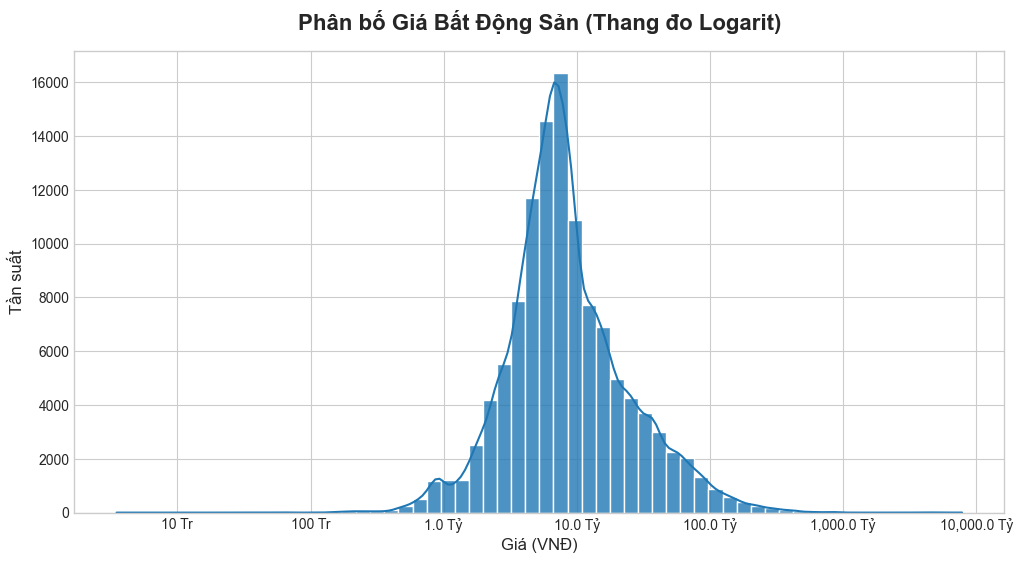

In [164]:
# Thiết lập style và kích thước biểu đồ
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12, 6))

# Vẽ biểu đồ phân bố tần suất 
sns.histplot(
    data=df_eda, 
    x='Gia', 
    bins=60, 
    color='#1f77b4',
    edgecolor='white',
    kde=True,
    log_scale=True,
    alpha=0.8
)

# Thiết lập tiêu đề và nhãn các trục
plt.title('Phân bố Giá Bất Động Sản (Thang đo Logarit)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Giá (VNĐ)', fontsize=12)
plt.ylabel('Tần suất', fontsize=12)

# Format trục X: Chuyển đổi hiển thị số khoa học sang định dạng 'Tỷ'/'Triệu'
formatter = ticker.FuncFormatter(lambda x, pos: f"{x/1e9:,.1f} Tỷ" if x >= 1e9 else f"{x/1e6:,.0f} Tr")
plt.gca().xaxis.set_major_formatter(formatter)

plt.show()


* **Nhận xét Phân Bố Giá:**
    * **Vùng giá "quốc dân":** Phần đỉnh cao nhất của biểu đồ tụ lại ở mốc **7 - 10 tỷ VNĐ**. Nhìn vào là thấy ngay đây là tầm giá có số lượng nhà đất được rao bán dày đặc và sôi động nhất trên thị trường.

    * **Sự cách biệt của giới siêu giàu:** Từ mốc sau 10 tỷ trở đi, số lượng giảm cắm đầu. Cái đuôi biểu đồ lác đác vài vạch nhưng kéo dài tít tắp về bên phải cho thấy: BĐS siêu sang (hàng trăm, hàng ngàn tỷ) tuy rất hiếm về mặt số lượng, nhưng giá của chúng bị lạm phát cách biệt cực kỳ xa so với mặt bằng chung.


### **2.2.2. Diện tích**

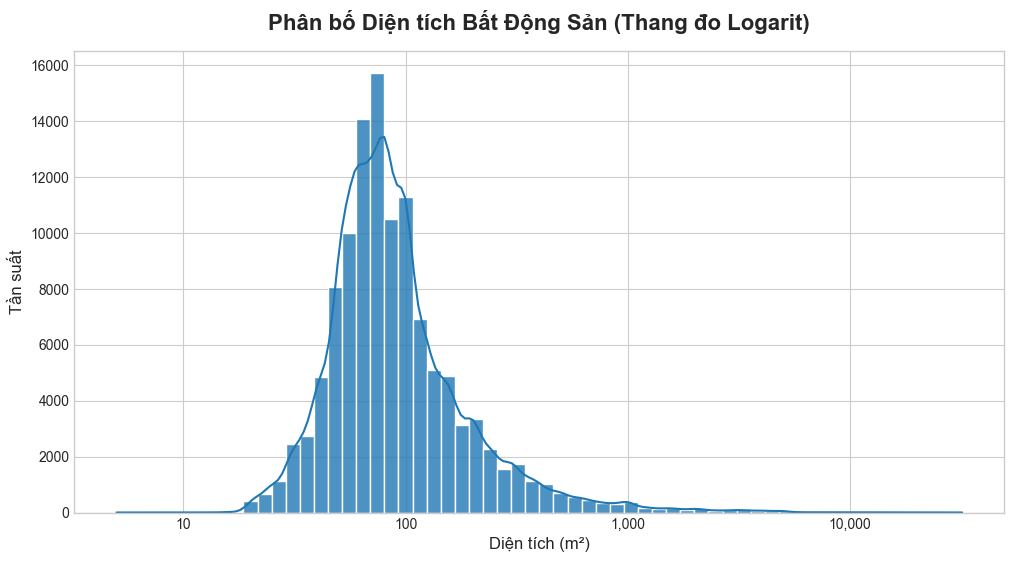

In [165]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12, 6))
# Vẽ biểu đồ Histogram cho Diện Tích 
sns.histplot(
    data=df_eda, 
    x='DienTich', 
    bins=60, 
    color='#1f77b4',
    edgecolor='white',
    kde=True,
    log_scale=True,
    alpha=0.8,
    line_kws={'color': 'red', 'linewidth': 1.5}
)
plt.title('Phân bố Diện tích Bất Động Sản (Thang đo Logarit)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Diện tích (m²)', fontsize=12)
plt.ylabel('Tần suất', fontsize=12)
# Format trục X: Hiển thị chữ số có dấu phẩy 
formatter = ticker.FuncFormatter(lambda x, pos: f"{x:,.0f}")
plt.gca().xaxis.set_major_formatter(formatter)
plt.show() 

* Nhận xét
    * **Diện tích:** Đỉnh chóp rao bán cực lớn tập trung ở **50m² - 100m²**, phản ánh đúng cung-cầu thực tế cho loại hình nhà phố và căn hộ gia đình ở TP.HCM
    
    * Vệt đuôi kéo rất dài sang mốc **1.000m² đến trên 10.000m²** bóc trần sự tồn tại của ngách bất động sản diện tích lớn (đất xưởng, đất nền dự án, kho bãi vùng ven).

* Kết luận: Nguồn cung chủ lực của TP.HCM đánh thẳng vào các loại hình nhà ở diện tích nhỏ gọn (đặc thù của siêu đô thị "đất chật người đông").

### **2.2.3. Giá/m2**

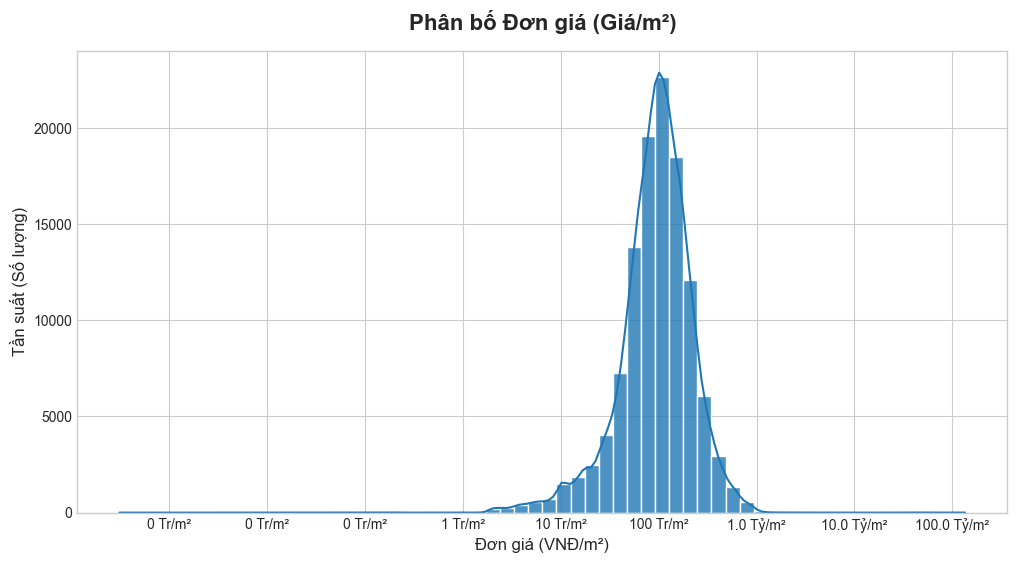

In [166]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12, 6))
# Vẽ biểu đồ Histogram (log-scale) cho Giá/m²
sns.histplot(
    data=df_eda, 
    x='Gia_m2', 
    bins=60, 
    color='#1f77b4',
    edgecolor='white',
    kde=True,
    log_scale=True,
    alpha=0.8,
    line_kws={'color': 'red', 'linewidth': 1.5}
)
plt.title('Phân bố Đơn giá (Giá/m²)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Đơn giá (VNĐ/m²)', fontsize=12)
plt.ylabel('Tần suất (Số lượng)', fontsize=12)
# Khắc phục định dạng 10^8: Hiển thị chữ 'Tr/m²' (dưới 1 tỷ) hoặc 'Tỷ/m²' (từ 1 tỷ trở lên)
formatter = ticker.FuncFormatter(lambda x, pos: f"{x/1e6:,.0f} Tr/m²" if x < 1e9 else f"{x/1e9:,.1f} Tỷ/m²")
plt.gca().xaxis.set_major_formatter(formatter)
plt.show() 

* Nhận xét
    * Đỉnh đồ thị minh chứng mức giá **100 Tr/m²** đang làm bá chủ. Đây là "định giá chuẩn" phổ biến nhất cho nhà đất tại TP.HCM.
    * Biên độ hội tụ:Đơn Giá/m² tụ tập khép kín và ken đặc ở vùng **60 Tr/m² - 150 Tr/m²**. 
* Kết luận: Dù nhà to hay nhà nhỏ, giá tiền tỷ hay chục tỷ, thì rốt cuộc mặt bằng chung của thị trường vẫn quy về một thước đo lõi là 100 triệu cho mỗi mét vuông.

## **3. Thống kê mô tả và phân tích các biến số phụ**

### **3.1. Tính thống kê mô tả cho các biến số phụ**

In [167]:
# Chọn các cột cần phân tích
cols_secondary_numeric = [
    'MatTien', 'DuongVao', 'ChieuRong', 'ChieuDai',
    'SoTang', 'SoPhongNgu', 'SoPhongVeSinh', 'SoPhongTam', 'ChoDeXe'
]
# Lọc ra các cột thực sự tồn tại trong df_eda
cols_secondary_numeric = [col for col in cols_secondary_numeric if col in df_eda.columns]

display(df_eda[cols_secondary_numeric].describe().T)

,count,mean,std,min,25%,50%,75%,max
MatTien,"116,863",728,"248,232",0,0,0,0,"84,858,689"
DuongVao,"116,863",3,25,0,0,0,3,"6,000"
ChieuRong,"116,863",0,2,0,0,0,0,101
ChieuDai,"116,863",1,7,0,0,0,0,"1,310"
SoTang,"116,863",1,2,0,0,0,0,330
SoPhongNgu,"116,863",2,5,0,0,2,3,710
SoPhongVeSinh,"116,863",2,4,0,0,1,3,168
SoPhongTam,"116,863",0,1,0,0,0,0,80
ChoDeXe,"116,863",0,0,0,0,0,0,1


* Nhận xét:
    - **Khuyết dữ liệu nặng:** Cột 50% (Trung vị) toàn bằng 0, lật tẩy việc dữ liệu người dùng nhập ban đầu bị trống rất nhiều (hệ quả của việc bù số 0 vào ở bước làm sạch).
    - **Tràn ngập Data xạo/ảo:** Nhìn qua cột Max, các số liệu bị spam vô tội vạ rành rành (Vd: Khai nhà có tới 710 phòng ngủ, hay mặt tiền dài 84 triệu mét).
* Kết luận: Dàn biến phụ này rác và nhiễu rất nặng. Khi có làm Mô hình sau này, chỉ dùng các thuật toán cực lì đòn (như Random Forest/XGBoost), hoặc an toàn nhất là ưu tiên xài các biến chính (Giá, Diện tích, Vị trí).

### **3.2 Trực quan hóa phân bố cho Mặt tiền, Đường vào, Chiều rộng, Chiều dài**

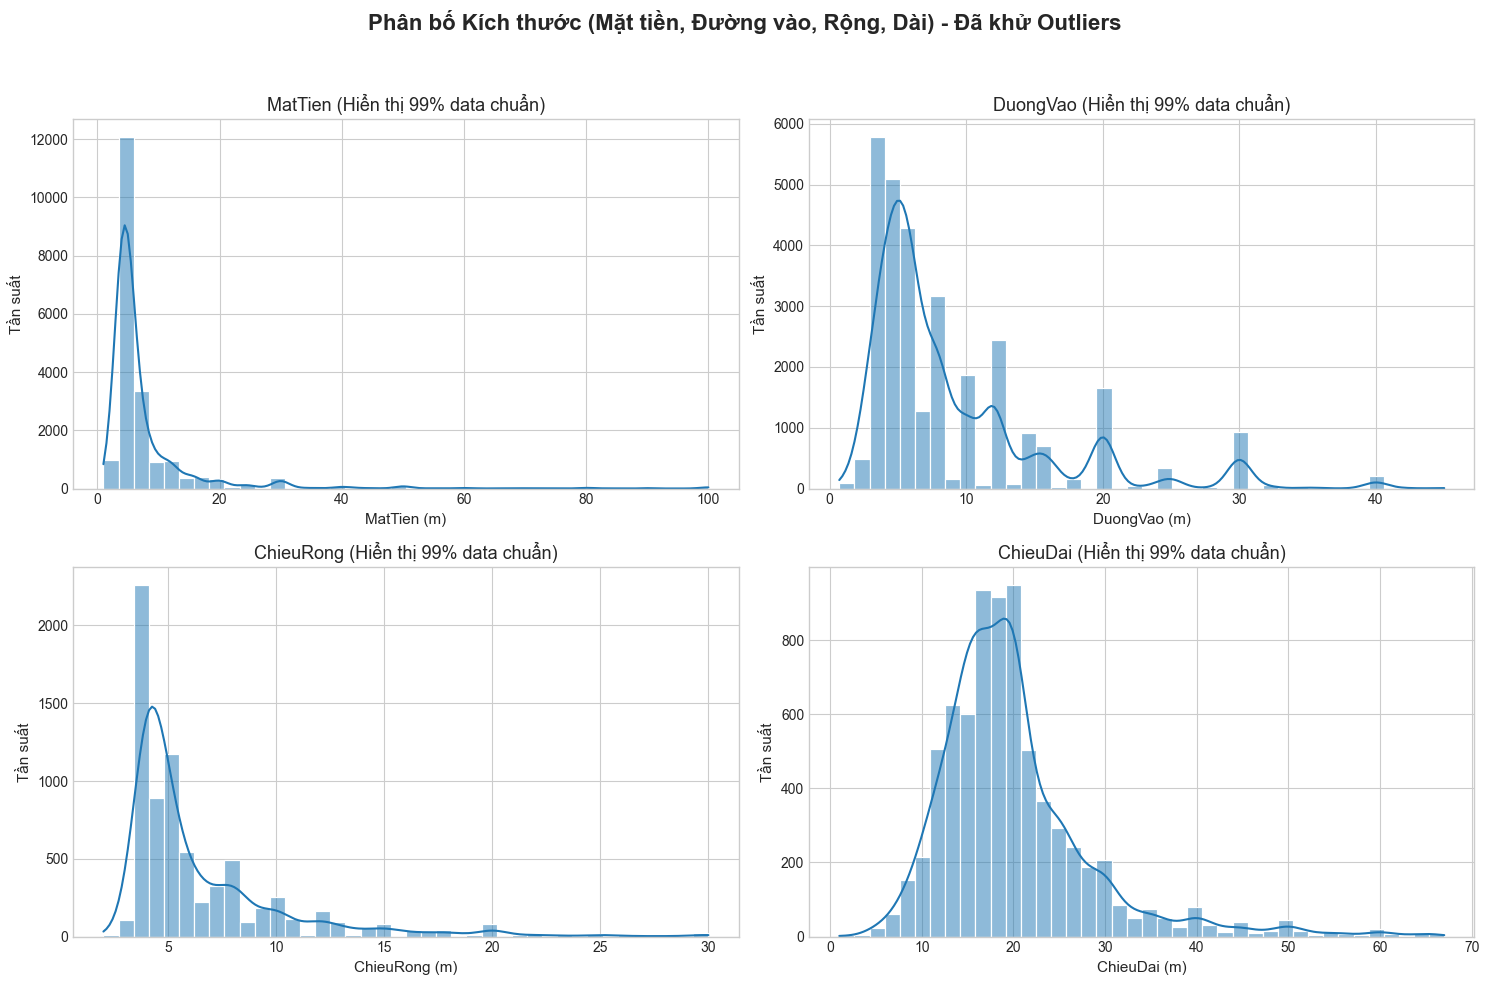

In [168]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Phân bố Kích thước (Mặt tiền, Đường vào, Rộng, Dài) - Đã khử Outliers', fontsize=16, fontweight='bold', y=0.98)
cols_dims = ['MatTien', 'DuongVao', 'ChieuRong', 'ChieuDai']
axes = axes.flatten()
for i, col in enumerate(cols_dims):
    if col in df_eda.columns:
        # Chỉ lấy các nhà có kích thước > 0
        s_positive = df_eda[df_eda[col] > 0][col]
        
        if not s_positive.empty:
            # Cắt bỏ 1% rác dữ liệu to khổng lồ phía trên cùng (Quantile 99%)
            q_99 = s_positive.quantile(0.99) 
            data_filtered = s_positive[s_positive <= q_99]
            
            # Vẽ lại với KDE để thấy rõ quả 
            sns.histplot(data_filtered, bins=40, kde=True, color='#1f77b4', edgecolor='white', ax=axes[i])
            axes[i].set_title(f'{col} (Hiển thị 99% data chuẩn)', fontsize=13)
            axes[i].set_xlabel(f'{col} (m)', fontsize=11)
            axes[i].set_ylabel('Tần suất', fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**Nhận xét (Kích thước):**
- **Kiểu mẫu "Nhà Ống":** Rộng/Mặt tiền chốt cứng ở mốc **4m-5m**, kết hợp Chiều dài **15m-20m**. Đây là format thiết kế phân lô nhà phố thống trị thị trường.
- **Phân loại hẻm/đường:** Cột Đường vào có hình răng cưa theo đúng chuẩn quy hoạch lộ giới: **~3m** (hẻm xe máy), **~5m** (hẻm ô tô), và **10-20m** (đường chính).
- **Chốt lại:** Nguồn cung 100% sinh ra để phục vụ nếp sống lõi đô thị chật hẹp, nhóm biệt thự/xưởng (mốc kích thước khổng lồ) chỉ chiếm thị phần rất mỏng.


### **3.3 Trực quan hóa tuần suất cho Số tầng, Số phòng ngủ, Số phòng vệ sinh, Số phòng tắm, Chỗ để xe**

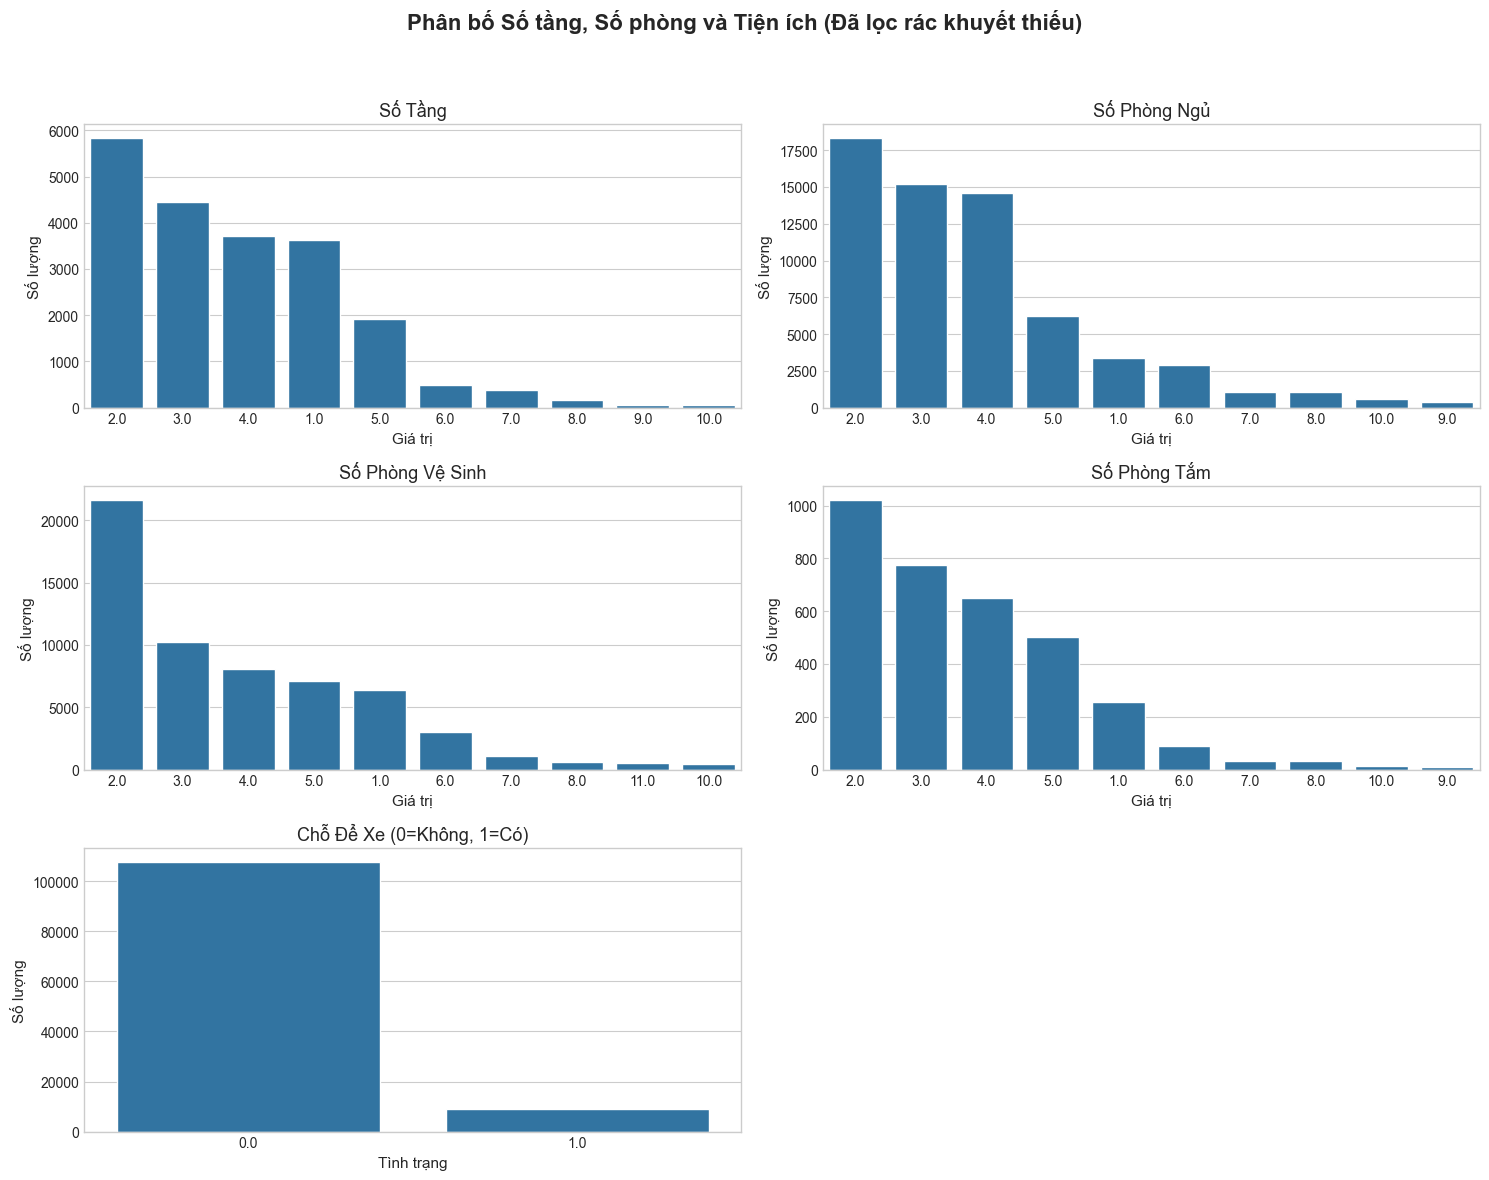

In [169]:
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle('Phân bố Số tầng, Số phòng và Tiện ích (Đã lọc rác khuyết thiếu)', fontsize=16, fontweight='bold', y=0.98)
axes = axes.flatten()

cols_counts = ['SoTang', 'SoPhongNgu', 'SoPhongVeSinh', 'SoPhongTam', 'ChoDeXe']
titles = ['Số Tầng', 'Số Phòng Ngủ', 'Số Phòng Vệ Sinh', 'Số Phòng Tắm', 'Chỗ Để Xe (0=Không, 1=Có)']

for i, col in enumerate(cols_counts):
    if col in df_eda.columns:
        # Lọc bỏ giá trị 0 (missing) cho phòng/tầng để nhìn rõ cấu trúc nhà thật
        if col != 'ChoDeXe':
            data_filtered = df_eda[df_eda[col] > 0]
        else:
            data_filtered = df_eda
            
        # Ưu tiên vớt top 10 giá trị phổ biến nhất để dọn rác outlies (hàng trăm phòng)
        order = data_filtered[col].value_counts().iloc[:10].index
        
        sns.countplot(
            x=col, data=data_filtered, ax=axes[i], order=order, 
            color='#1f77b4', edgecolor='white'
        )
        
        axes[i].set_title(titles[i], fontsize=13)
        axes[i].set_xlabel('Giá trị' if col != 'ChoDeXe' else 'Tình trạng', fontsize=11)
        axes[i].set_ylabel('Số lượng', fontsize=11)
        axes[i].tick_params(axis='x', rotation=0) 
    else:
        axes[i].set_title(f'{titles[i]} (Không tồn tại)')

if len(cols_counts) < len(axes):
    for j in range(len(cols_counts), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


**Nhận xét (Phòng & Tầng):**
- **Kiến trúc "quốc dân":** Số Tầng, Phòng ngủ, và Vệ sinh đều chốt cứng ở bộ ba mốc **2, 3, và 4**. Đây là format thiết kế "quốc dân" (căn hộ 2-3 phòng ngủ, nhà phố 2-4 tầng) 100% chuẩn với thị giác thực tế.
- **Biến thiếu hụt:** Cột `Phòng Tắm` có lượng data rớt thảm hại (chỉ lèo tèo mốc 1000 căn, bé tí so với 20.000 căn có Phòng Vệ Sinh). `Chỗ để xe = 0` áp đảo 90%, phản ánh thói quen đăng tin thiếu chi tiết hoặc đặc thù nhà hẻm (không bãi đỗ).


## **4. Phân tích các biến phân loại**

### **4.1 Thống kê tuần suất**


In [170]:
print("\n Phân bố cho cột: QuanHuyen")
col = 'QuanHuyen'
if col in df_eda.columns:
    counts_qh = df_eda[col].value_counts()
    percentages_qh = df_eda[col].value_counts(normalize=True) * 100
    
    # Tạo DataFrame để hiển thị đẹp hơn
    stats_qh = pd.DataFrame({'SoLuong': counts_qh, 'TyLe_%': percentages_qh.round(1)})
    
    # Hiển thị tất cả các hạng mục
    display(stats_qh)
else:
    print(f" Cột '{col}' không tồn tại.")


 Phân bố cho cột: QuanHuyen


,SoLuong,TyLe_%
QuanHuyen,,
Thủ Đức,27008,23
Tân Bình,8652,7
Bình Tân,8495,7
Gò Vấp,8075,7
Quận 7,7592,6
Bình Thạnh,7461,6
Quận 12,7284,6
Tân Phú,7113,6
Bình Chánh,4616,4


In [171]:
print("\n Phân bố cho cột: LoaiBDS")
col = 'LoaiBDS'
if col in df_eda.columns:
    counts_lb = df_eda[col].value_counts()
    percentages_lb = df_eda[col].value_counts(normalize=True) * 100
    
    stats_lb = pd.DataFrame({'SoLuong': counts_lb, 'TyLe_%': percentages_lb.round(1)})
    
    # Hiển thị tất cả các hạng mục
    display(stats_lb)
else:
    print(f" Cột '{col}' không tồn tại.")


 Phân bố cho cột: LoaiBDS


,SoLuong,TyLe_%
LoaiBDS,,
Nhà,65689,56
Đất,22980,20
Không xác định,11831,10
Căn hộ,11614,10
Biệt thự,4749,4


In [172]:
print("\n Phân bố cho cột: Nguon")
col = 'Nguon'
if col in df_eda.columns:
    counts_ng = df_eda[col].value_counts()
    percentages_ng = df_eda[col].value_counts(normalize=True) * 100
    
    stats_ng = pd.DataFrame({'SoLuong': counts_ng, 'TyLe_%': percentages_ng.round(1)})
    
    # Hiển thị tất cả các hạng mục
    display(stats_ng)
else:
    print(f" Cột '{col}' không tồn tại.")


 Phân bố cho cột: Nguon


,SoLuong,TyLe_%
Nguon,,
batdongsan,69225,59
nhadat24h,33122,28
alonhadat,8133,7
meeyland,6383,6


### **4.2 Trực quan hóa các biến phân loại**

#### **4.2.1 Top 15 quận huyện phổ biến nhất**

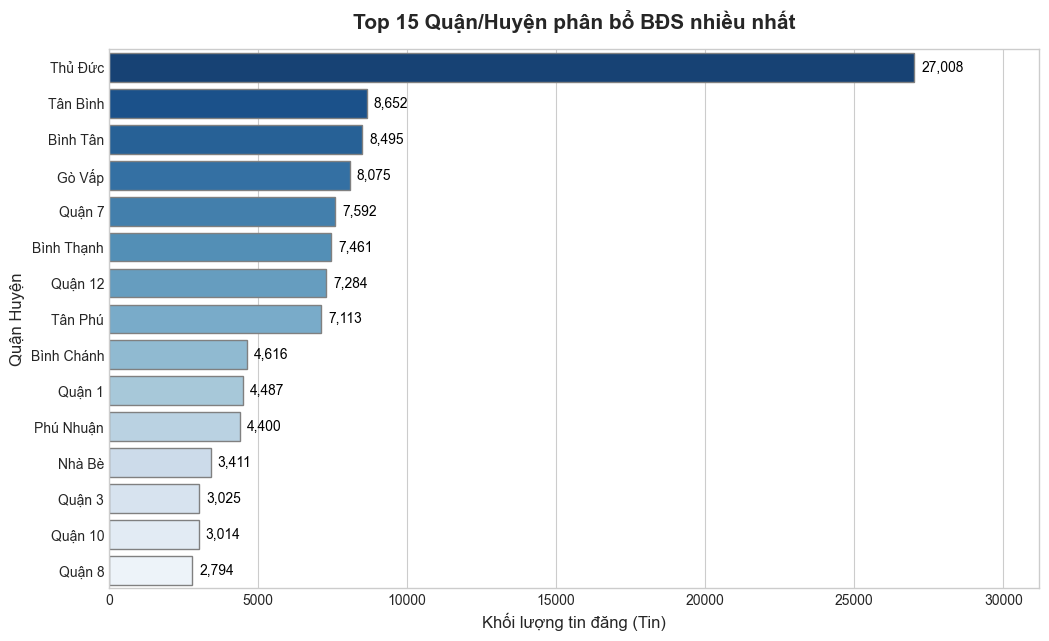

In [173]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12, 7))

# Trích xuất top 15 quận huyện có dòng dữ liệu nhiều nhất
top_15_quan = df_eda['QuanHuyen'].value_counts().iloc[:15].index

# Khởi tạo biểu đồ thanh ngang (Horizontal Bar Chart)
ax = sns.countplot(
    y='QuanHuyen', 
    data=df_eda, 
    order=top_15_quan, 
    palette='Blues_r', 
    edgecolor='gray'
)

# Gắn nhãn dữ liệu thực tế (Data Labels)
for container in ax.containers:
    ax.bar_label(container, padding=5, fmt='{:,.0f}', color='black')

# Định dạng tiêu đề vĩ mô và thiết lập trục tọa độ
plt.title('Top 15 Quận/Huyện phân bổ BĐS nhiều nhất', fontsize=15, weight='bold', pad=15)
plt.xlabel('Khối lượng tin đăng (Tin)', fontsize=12)
plt.ylabel('Quận Huyện', fontsize=12)

plt.xlim(0, ax.get_xlim()[1] * 1.1)

plt.show()


* Nhận xét
    * Biểu đồ Top 15 cho thấy sự phân bố tin đăng không đồng đều giữa các quận.
    * Thành phố Thủ Đức là khu vực có số lượng tin đăng cao vượt trội (hơn 25.000 tin), nhiều hơn gấp đôi so với quận đứng thứ hai là Tân Bình.
    * Các quận/huyện còn lại: Tân Bình, Bình Tân, Gò Vấp, Quận 7, Quận 12, Bình Thạnh, Tân Phú có số lượng đăng tin xem xem nhau ( khoảng 7000 - 9000 tin)
    * Các quận Bình Chánh, Quận 1, Phú Nhuận, Nhà Bè, Quận 3, Quận 10, Quận 8 số lượng thấp (dưới 5000 tin)

#### **4.2.2 Biểu đồ cho LoaiBDS**

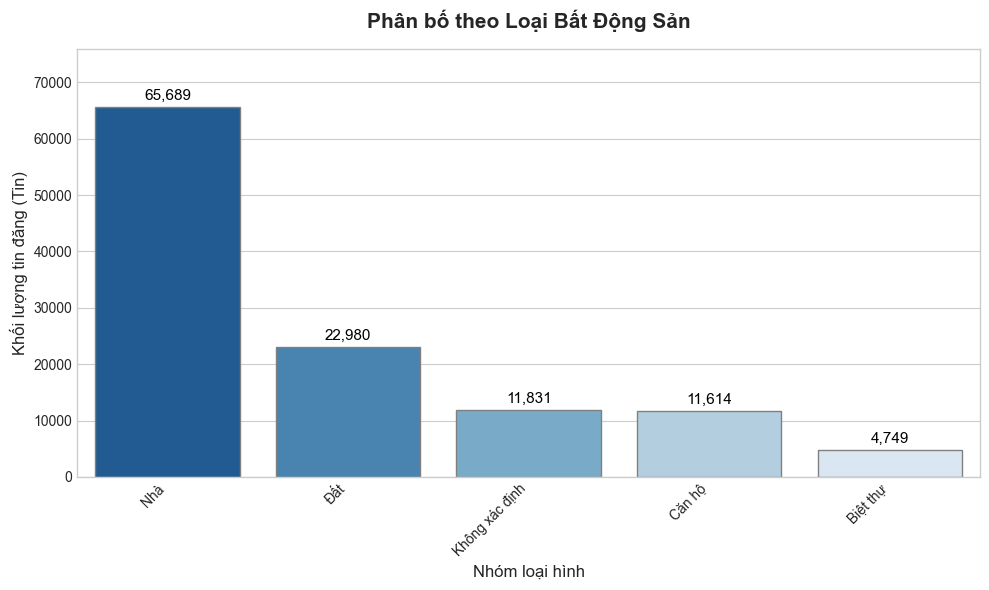

In [174]:
plt.figure(figsize=(10, 6))

# Thu thập chuỗi giá trị và đồng bộ xếp hạng từ cao xuống thấp
order_bds = df_eda['LoaiBDS'].value_counts().index

# Khởi tạo biểu đồ cột dọc Vertical Bar Chart
ax = sns.countplot(
    x='LoaiBDS', 
    data=df_eda, 
    palette='Blues_r', 
    order=order_bds,
    edgecolor='gray'
)

# Trích xuất số liệu thực và ép (Gắn Label) lên ngọn từng cột
# Lặp qua tất cả list container do dải màu đẻ ra để dán nhãn toàn bộ
for container in ax.containers:
    ax.bar_label(container, padding=3, fmt='{:,.0f}', color='black', fontsize=11)

# Tiêu chuẩn hóa tiêu đề biểu đồ và thiết kế nhãn 2 cạnh X-Y
plt.title('Phân bố theo Loại Bất Động Sản', fontsize=15, weight='bold', pad=15)
plt.xlabel('Nhóm loại hình', fontsize=12)
plt.ylabel('Khối lượng tin đăng (Tin)', fontsize=12)

# Xoay chữ nhãn dưới trục X đi 45 độ tránh cho text đè vào nhau 
plt.xticks(rotation=45, ha='right')

plt.ylim(0, ax.get_ylim()[1] * 1.1)

plt.tight_layout()
plt.show()


* Nhận xét
    * Loại hình "Nhà" chiếm đa số tuyệt đối trong tập dữ liệu, với số lượng cao hơn hẳn các loại hình khác (hơn 60.000 tin)
    * "Đất" là loại hình phổ biến thứ hai (gần 23.000 tin), tiếp theo là "Căn hộ", "Không xác định"và "Biệt thự" chiếm tỷ lệ nhỏ nhất (dưới 12.000 tin)

#### **4.2.3. Biểu đồ cho Nguồn Đăng Tin**

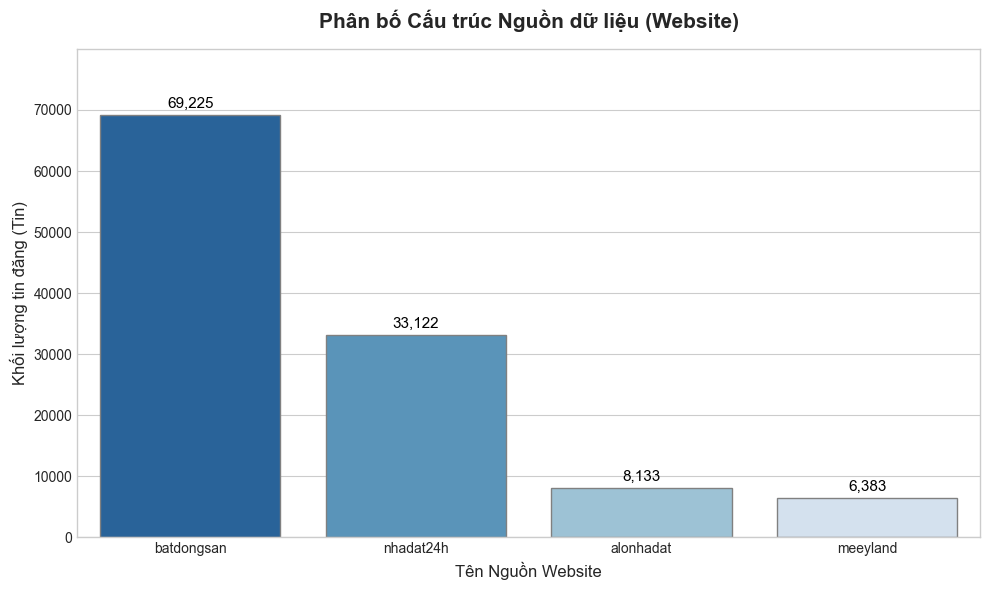

In [175]:
plt.figure(figsize=(10, 6))

# Thu thập chuỗi giá trị và đồng bộ xếp hạng từ cao xuống thấp
order_nguon = df_eda['Nguon'].value_counts().index

# Khởi tạo biểu đồ cột dọc Vertical Bar Chart
ax = sns.countplot(
    x='Nguon', 
    data=df_eda, 
    palette='Blues_r', 
    order=order_nguon,
    edgecolor='gray'
)

# Trích xuất số liệu thực và ép (Gắn Label) lên ngọn từng cột
for container in ax.containers:
    ax.bar_label(container, padding=3, fmt='{:,.0f}', color='black', fontsize=11)

# Tiêu chuẩn hóa tiêu đề biểu đồ và thiết kế nhãn 2 cạnh X-Y
plt.title('Phân bố Cấu trúc Nguồn dữ liệu (Website)', fontsize=15, weight='bold', pad=15)
plt.xlabel('Tên Nguồn Website', fontsize=12)
plt.ylabel('Khối lượng tin đăng (Tin)', fontsize=12)

plt.ylim(0, ax.get_ylim()[1] * 1.1)

plt.tight_layout()
plt.show()


* Nhận xét
    * Nguồn batdongsan đóng góp lượng dữ liệu lớn nhất, chiếm hơn một nửa tổng số tin đăng (gần 70.000 tin)
    * nhadat24h là nguồn lớn thứ hai (khoảng 33.000 tin), theo sau là alonhadat và meeyland với số lượng ít hơn đáng kể (dưới 10.000 tin)

## **5. Phân tích mối quan hệ giữa các biến số**

### **5.1 Tạo Ma trận tương quan**

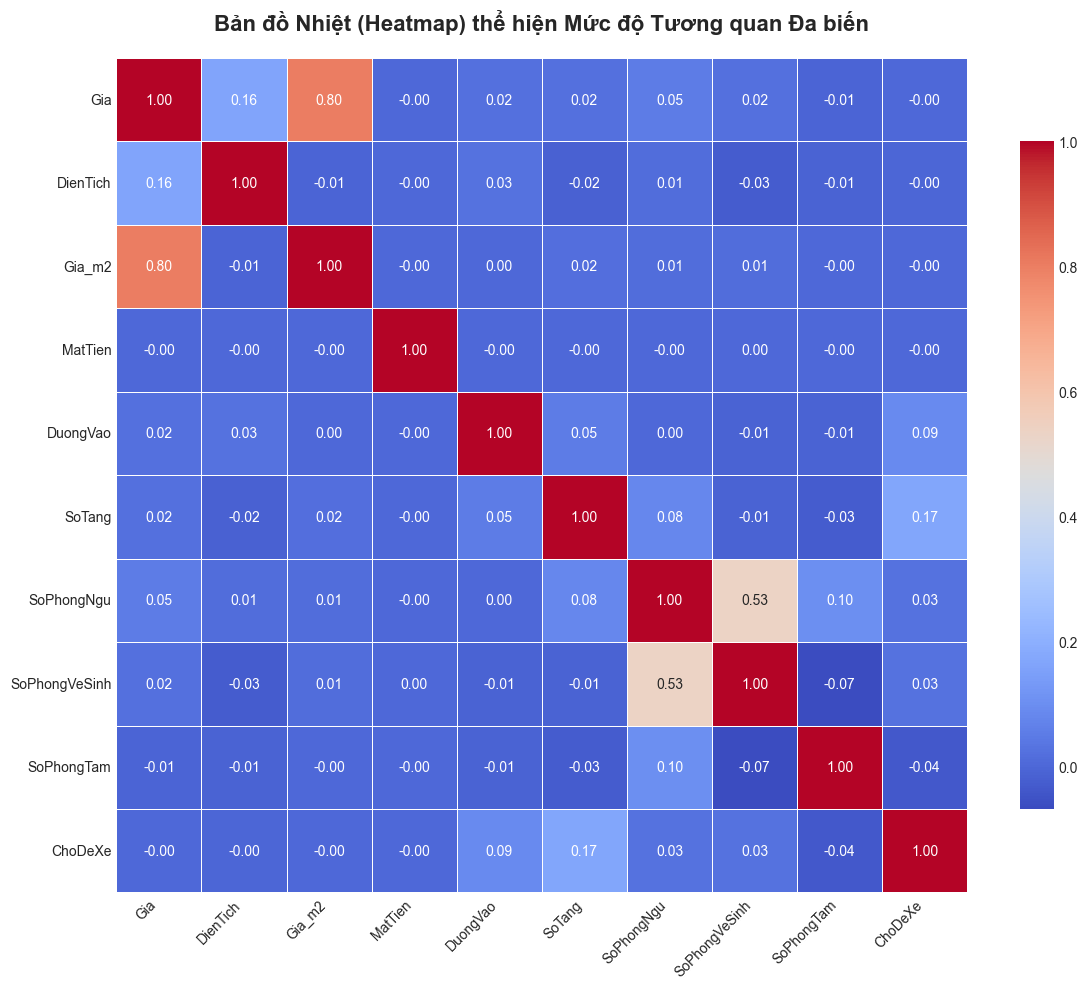

BẢNG XẾP HẠNG MỨC ĐỘ ẢNH HƯỞNG TỚI GIÁ BÁN


Gia              1
Gia_m2           1
DienTich         0
SoPhongNgu       0
SoPhongVeSinh    0
DuongVao         0
SoTang           0
MatTien         -0
ChoDeXe         -0
SoPhongTam      -0
Name: Gia, dtype: float64

In [176]:
# 1. Khai báo danh sách các biến số học (Numeric) cần đưa vào "soi" ma trận
numeric_cols = [
    'Gia', 'DienTich', 'Gia_m2', 'MatTien', 'DuongVao', 
    'SoTang', 'SoPhongNgu', 'SoPhongVeSinh', 'SoPhongTam', 'ChoDeXe'
]

# Lọc mảng an toàn (bảo hiểm cho trường hợp lỡ tay drop mất cột nào đó)
numeric_cols = [col for col in numeric_cols if col in df_eda.columns]

# 2. Tính toán Ma Trận Tương Quan (Pearson)
corr_matrix = df_eda[numeric_cols].corr()

# 3. Trực quan hóa bằng Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm',         # Dải màu Đỏ (Tương quan dương) - Xanh (Chống nhau/Khuyết)
    fmt='.2f', 
    linewidths=0.5,
    cbar_kws={"shrink": .8}  # Thu gọn thanh chú giải bên phải 1 chút cho cân đối
)

plt.title('Bản đồ Nhiệt (Heatmap) thể hiện Mức độ Tương quan Đa biến', fontsize=16, weight='bold', pad=20)
plt.xticks(rotation=45, ha='right') 

plt.tight_layout()
plt.show()

# 4. Trích xuất sức ảnh hưởng trực tiếp đến cột mục tiêu (Giá)
print("BẢNG XẾP HẠNG MỨC ĐỘ ẢNH HƯỞNG TỚI GIÁ BÁN")
corr_gia = corr_matrix['Gia'].sort_values(ascending=False)
display(corr_gia)


**Nhận xét Ma trận Tương quan:**
- **Chân lý Đơn giá:** Tổng tiền (`Gia`) bị kéo theo cực mạnh bởi Đơn giá (`Gia_m2`) với $r=0.80$. Trong khi Diện tích nhạt nhòa ở mức $r=0.16$. Insight thị trường quá gắt: Mua nhà Sài Gòn thì Vị trí (đơn giá) định hình độ đắt đỏ chứ không phải Đất to hay nhỏ

- **Biến phụ:** Mặt tiền, Khoảng đùi, Tầng... bị ghim chết ở mốc tẻ nhạt $0.00$. Điểm mù này tố giác việc rác dữ liệu lấp bằng số 0 đã gián tiếp phá vỡ toàn bộ mối liên hệ tự nhiên của tụi nó với Giá bán.



### **5.2 Trực quan hóa Tương quan: Giá vs. Diện tích (Scatter Plot)**

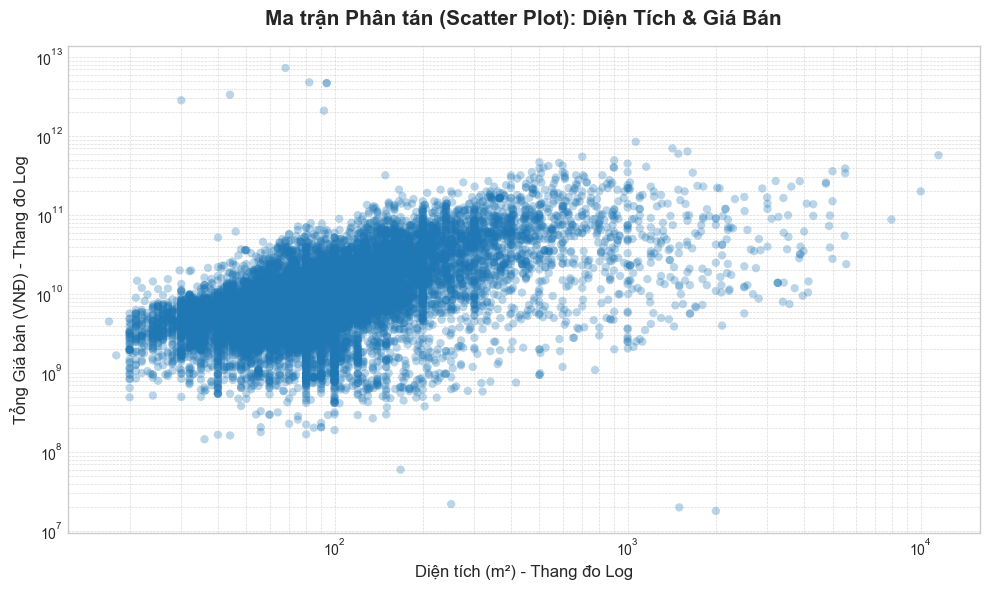

In [177]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(10, 6))

# Lấy ngẫu nhiên 20,000 mẫu để chống chặn hiện tượng Overplotting (nhòe mực, kẹt điểm)
df_sample = df_eda.sample(n=min(20000, len(df_eda)), random_state=42) 

# Vẽ Scatter Plot, ép màu Xanh tĩnh lặng (#1f77b4) và giảm alpha để nhìn thấu độ đặc của cụm
sns.scatterplot(
    data=df_sample, 
    x='DienTich', 
    y='Gia', 
    color='#1f77b4', 
    alpha=0.3, 
    edgecolor='None'
)

plt.title('Ma trận Phân tán (Scatter Plot): Diện Tích & Giá Bán', fontsize=15, weight='bold', pad=15)
plt.xlabel('Diện tích (m²) - Thang đo Log', fontsize=12)
plt.ylabel('Tổng Giá bán (VNĐ) - Thang đo Log', fontsize=12)

# Ép 2 trục về thang Log để ép cụm Outliers khổng lồ vào lọt thỏm trong 1 khung hình
plt.xscale('log')
plt.yscale('log')

# Phẩy thêm lưới Grid để sếp dễ gióng số
plt.grid(True, which="both", ls="--", linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.show()


* Nhận xét 

    * Đám mây đồ thị có xu hướng nhếch chéo nhẹ lên (Diện rộng -> Giá tăng). THẾ NHƯNG, nó bị phình cực to theo phương thẳng đứng. Nhìn vào trục $10^2$ (tương đương nhà 100m²), khoảng giá bị cày nát lộn xộn từ 2 Tỷ vọt lên tận 30 Tỷ. 

    * Độ nhiễu loạn của đám mây thẳng đứng chứng minh rõ rệt: Kích thước miếng đất không phải là thứ thống trị bảng giá.

* Kết luận: Khẳng định bằng thị giác một lần nữa chân lý của BĐS ở Sài Gòn là Vị trí. Đơn giá của khu đất mới là ông trùm quyết định số tiền, diện tích to chỉ làm nền mà thôi


### **5.3 Trực quan hóa Mối quan hệ: Giá vs. Số Phòng Ngủ (Boxplot)**

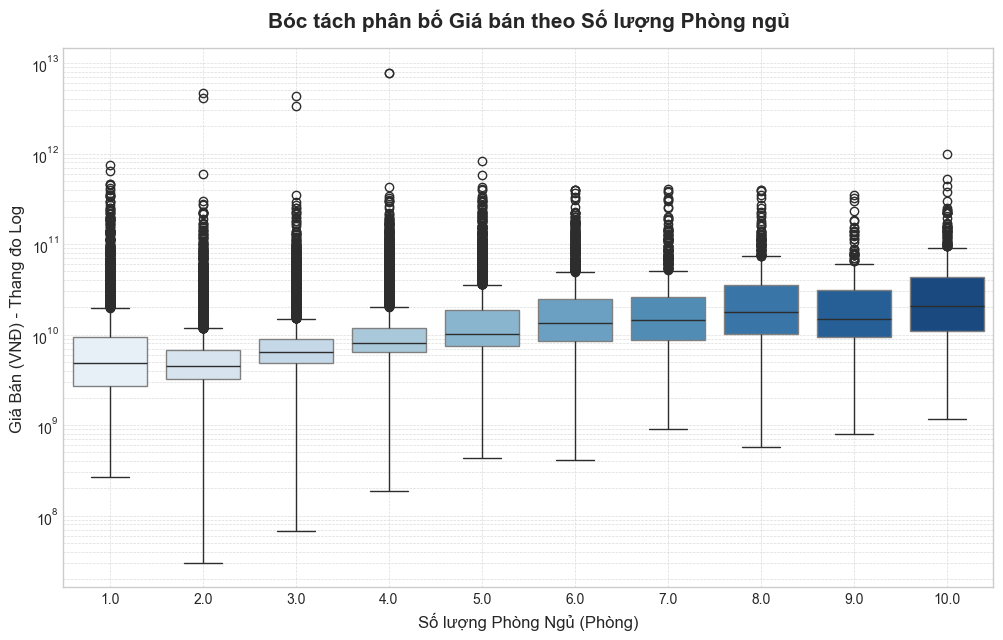

In [178]:
# Vì SoPhongNgu là biến rời rạc, dùng boxplot sẽ lột tả được dải phân bố tốt hơn
# Lọc bỏ rác 0 và các căn dị biệt (>10 phòng) để nhìn rõ trend
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12, 7))

data_phongngu_filtered = df_eda[(df_eda['SoPhongNgu'] > 0) & (df_eda['SoPhongNgu'] <= 10)]

# Vẽ hộp Boxplot, dùng palette='Blues' (Số phòng tăng thì màu bầm đậm lên)
sns.boxplot(
    data=data_phongngu_filtered, 
    x='SoPhongNgu', 
    y='Gia', 
    palette='Blues',  
    boxprops=dict(edgecolor='gray') 
)

plt.title('Bóc tách phân bố Giá bán theo Số lượng Phòng ngủ', fontsize=15, weight='bold', pad=15)
plt.xlabel('Số lượng Phòng Ngủ (Phòng)', fontsize=12)
plt.ylabel('Giá Bán (VNĐ) - Thang đo Log', fontsize=12)

# Ép trục Y về log để bao trọn dàn mây Outlier giăng chi chít bên trên
plt.yscale('log')

# Giăng lưới cho dễ gióng vạch
plt.grid(True, which="both", ls="--", linewidth=0.5, alpha=0.7)

plt.show()


**Nhận xét (Giá vs. Phòng ngủ):**

- **Bậc thang Giá:** Đường trung vị leo dốc tịnh tiến rất nét từ mốc 2 lên 6 phòng. Quy luật cứng: Càng đẻ nhiều phòng, giá sàn mặc định càng bị đẩy lên cao.
- **Vùng nhiễu loạn (7-10 phòng):** Càng chóp trên thân hộp càng phình to bấn loạn. Đây là khoảng giá bị pha tạp giữa Biệt thự siêu sang (rất đắt) và Dãy nhà trọ sinh viên (nhiều phòng nhưng rẻ).



## **6. Phân tích mối quan hệ giữa biến Phân loại và biến số (tập trung vào giá)**

### **6.1 So sánh Giá giữa các quận**

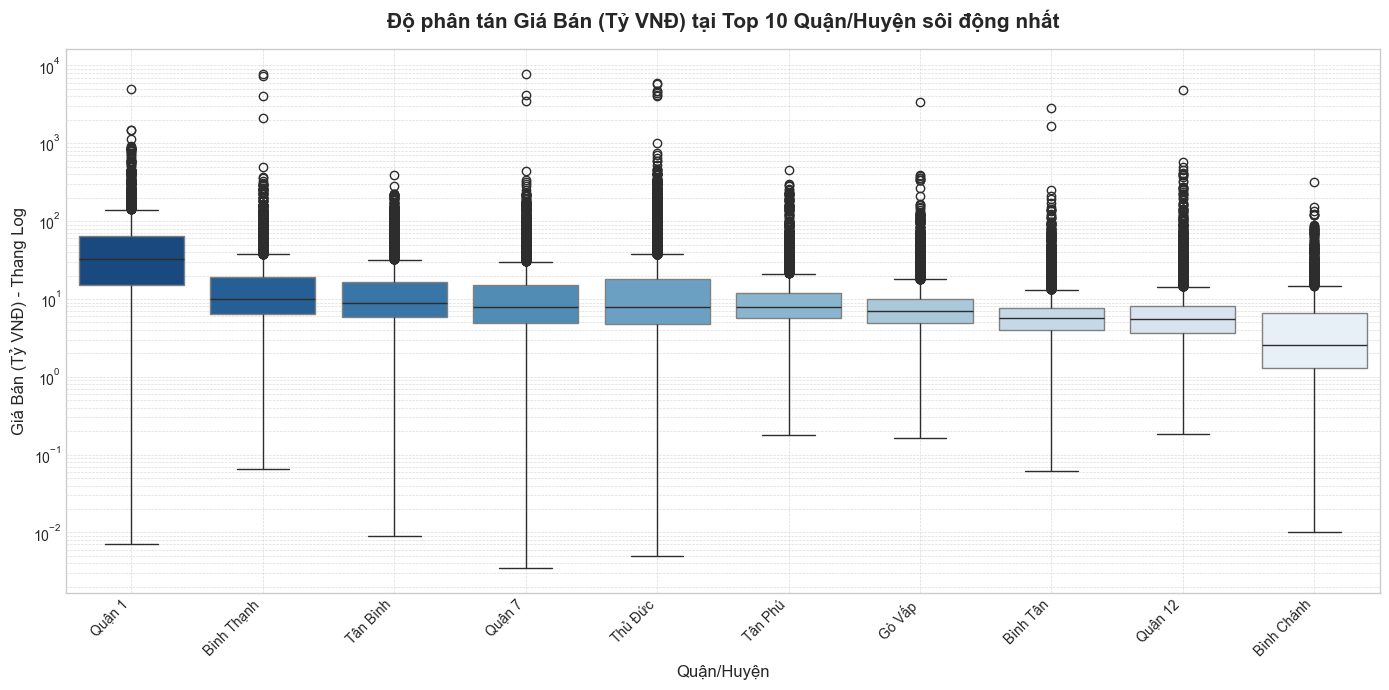

In [179]:
plt.style.use('seaborn-v0_8-whitegrid')

# 1. Lọc ra danh sách Top 12 Quận/Huyện có nhiều data nhất (Lọc bỏ các huyện ven lèo tèo vài mống)
top_10_valid = df_eda['QuanHuyen'].value_counts().head(10).index.tolist()

# 2. Tạo dataframe chỉ chứa 12 quận này và Giá > 0
df_quan_plot = df_eda[(df_eda['QuanHuyen'].isin(top_10_valid)) & (df_eda['Gia'] > 0)].copy()

# Đổi sang hệ Tỷ VNĐ cho trục Y gọn gàng
df_quan_plot['Gia_ty'] = df_quan_plot['Gia'] / 1e9

# 3. Sắp xếp các Quận giảm dần theo Giá Trung Vị (Nhìn phát biết khu nào nhà giàu nhất)
order_quan = df_quan_plot.groupby('QuanHuyen')['Gia_ty'].median().sort_values(ascending=False).index

# 4. Vẽ Boxplot
plt.figure(figsize=(14, 7))

# Dùng dải màu Blues_r để nhấn mạnh độ giàu có giảm dần
sns.boxplot(
    data=df_quan_plot, 
    x='QuanHuyen', 
    y='Gia_ty', 
    order=order_quan, 
    palette='Blues_r', 
    boxprops=dict(edgecolor='gray')
)

plt.title('Độ phân tán Giá Bán (Tỷ VNĐ) tại Top 10 Quận/Huyện sôi động nhất', fontsize=15, weight='bold', pad=15)
plt.xlabel('Quận/Huyện', fontsize=12)
plt.ylabel('Giá Bán (Tỷ VNĐ) - Thang Log', fontsize=12)

plt.xticks(rotation=45, ha='right')

# VŨ KHÍ BÍ MẬT: Ép trục Y về LOG để cho phép vạch trung vị của nhà bình dân (1-10 tỷ) nở ra dễ soi
plt.yscale('log')

# Giăng lưới
plt.grid(True, which="both", ls="--", linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.show()


**Nhận xét Độ phân tán Giá theo Quận:**
- **Đẳng cấp Quận 1:** Hộp trung vị của Quận 1 treo lơ lửng ở vị thế thượng tôn (quanh mốc ~30 Tỷ), bỏ đứng các quận "thường dân" bám đuổi đằng sau.
- **Trượt giá theo ly tâm:** Sau Quận 1, trục giá trượt dốc đều đặn từ Bình Thạnh kéo dãn ra đâm thẳng xuống ngoại thành Huyện Bình Chánh (gãy hẳn xuống sàn 2-3 Tỷ).
- **"Biển" Outliers cảnh báo:** Nhìn chóp trên của tất cả các Hộp, hàng ngàn chấm đen (Outlier) đâm thủng trần cả mốc ngàn Tỷ. Nó minh chứng rõ ràng: Ở các rốn giao dịch sôi động này, tin rác (spam giá lùa gà, nhập lố số 0) hoặc các cú chốt biệt thự cực khủng đang hỗn chiến với nhau.


### **6.2 So sánh Giá giữa các loại BĐS**

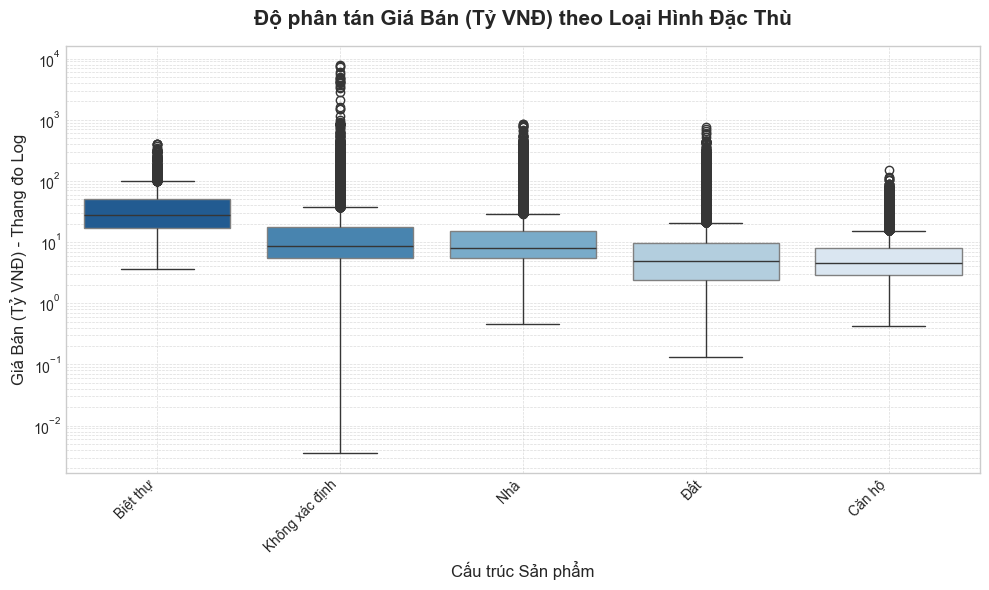

In [180]:
plt.style.use('seaborn-v0_8-whitegrid')

# Lọc bỏ dữ liệu rác (Giá=0 hoặc Loại BĐS bị trống)
df_loai_plot = df_eda[df_eda['LoaiBDS'].notna() & (df_eda['Gia'] > 0)].copy()

# Đưa trục Y về hệ Tỷ VNĐ
df_loai_plot['Gia_ty'] = df_loai_plot['Gia'] / 1e9

# Giữ nguyên thứ tự giảm dần theo độ "Sang chảnh" của trung vị
order_loai = df_loai_plot.groupby('LoaiBDS')['Gia_ty'].median().sort_values(ascending=False).index

plt.figure(figsize=(10, 6))

# Đẩy palette Xanh tịnh tiến dần vào
sns.boxplot(
    data=df_loai_plot, 
    x='LoaiBDS', 
    y='Gia_ty', 
    order=order_loai, 
    palette='Blues_r',
    boxprops=dict(edgecolor='gray')
)

plt.title('Độ phân tán Giá Bán (Tỷ VNĐ) theo Loại Hình Đặc Thù', fontsize=15, weight='bold', pad=15)
plt.xlabel('Cấu trúc Sản phẩm', fontsize=12)
plt.ylabel('Giá Bán (Tỷ VNĐ) - Thang đo Log', fontsize=12)

plt.xticks(rotation=45, ha='right')

# LUÔN LUÔN NHỚ: Ép trục Y về LOG để kéo giãn các hộp đang bị nhốt dưới đáy
plt.yscale('log')

plt.grid(True, which="both", ls="--", linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.show()


**Nhận xét Phân tầng theo Cấu trúc BĐS:**
- **Đế vương Biệt thự:** Hộp trung vị cao nhất bảng, vượt trội hoàn toàn về mặt bằng sàn. Đây chính là cứ điểm dốc túi của phân khúc xa xỉ.
- **Rổ rác "Không xác định":** Thân hộp bị kéo dãn dài ngoằng, biên độ dao động cực kỳ bát nháo. Báo động đỏ: Nhóm giấu mặt này chứa đầy tin ảo, "treo đầu dê bán thịt chó" với đủ mọi mức giá trên trời dưới biển.
- **Sự chuẩn mực của Căn hộ:** Nằm yên vị ở mốc rẻ nhất, hộp gầy nhom nhỏ nhắn chứng tỏ biên độ giá dao động rất hẹp. Rút ra kết luận: Căn hộ là phân khúc đại chúng có khung định giá ổn định, minh bạch và ít bị lùa gà bơm thổi nhất thị trường.


### **6.3 Thống kê Giá trung bình và trung vị theo Quận và theo loại BĐS**

#### **6.3.1 Thống kê Giá trung bình và Giá trung vị theo Quận**

Thống kê TOP 20 Quận (sắp xếp theo mặt bằng giá sàn - Giá trung vị):


,So_luong,Gia_TrungVi_ty,Gia_TB_ty,Gia_STD
QuanHuyen,,,,
Quận 1,4487,33,59,"117,827,465,781"
Quận 5,1015,14,25,"29,987,717,744"
Quận 3,3025,12,40,"74,175,821,473"
Quận 10,3014,11,20,"28,905,547,796"
Bình Thạnh,7461,10,22,"135,974,277,654"
Phú Nhuận,4400,10,20,"33,641,762,085"
Cần Giờ,277,9,17,"25,864,974,165"
Tân Bình,8652,9,16,"22,231,840,312"
Quận 11,857,8,14,"22,557,893,295"


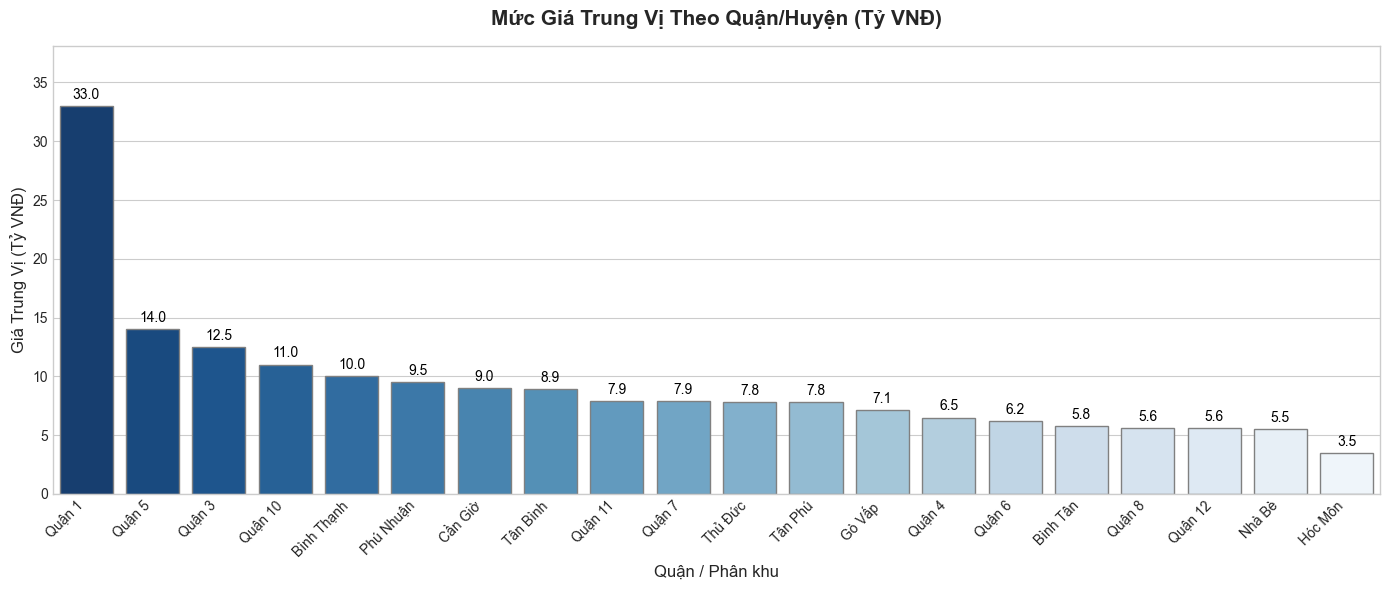

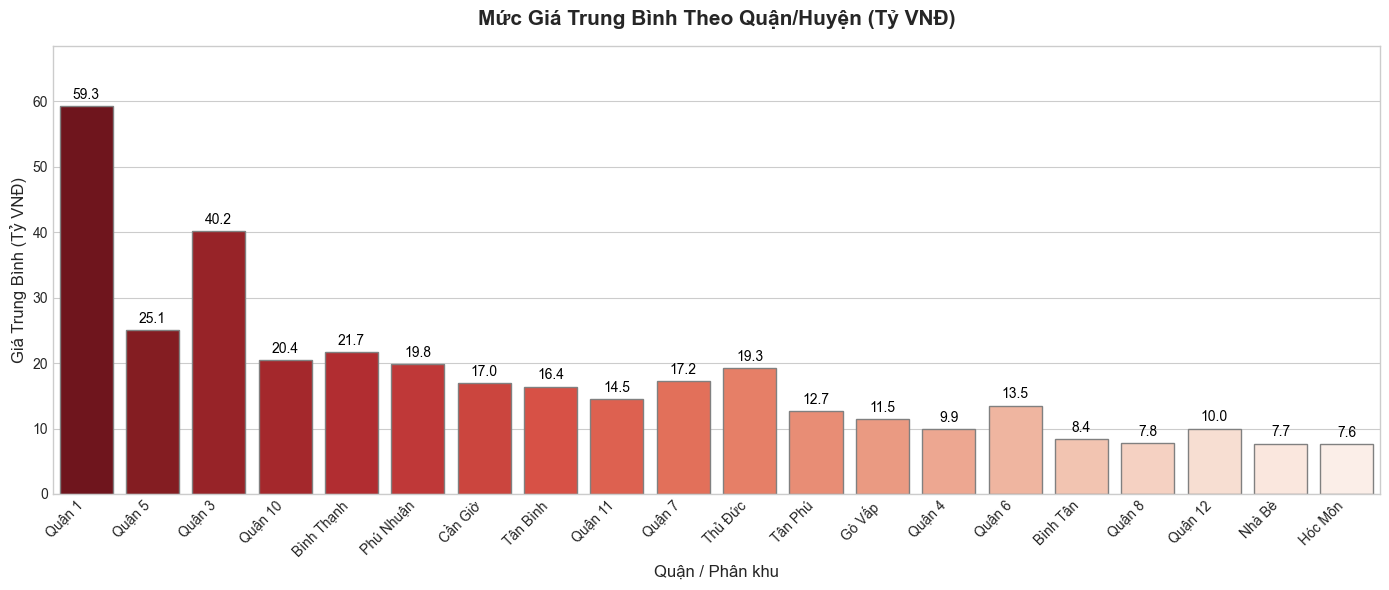

In [181]:
# THỐNG KÊ CHI TIẾT THEO QUẬN 
gia_theo_quan = df_eda[df_eda['Gia'] > 0].groupby('QuanHuyen').agg(
    So_luong=('Gia', 'count'),
    Gia_TB=('Gia', 'mean'),
    Gia_TrungVi=('Gia', 'median'),
    Gia_STD=('Gia', 'std')
).sort_values('Gia_TrungVi', ascending=False)

# Ép sang hệ tỷ để dể nhẩm và in thẳng lên biểu đồ
gia_theo_quan['Gia_TrungVi_ty'] = (gia_theo_quan['Gia_TrungVi'] / 1e9).round(1)
gia_theo_quan['Gia_TB_ty'] = (gia_theo_quan['Gia_TB'] / 1e9).round(1)

print("Thống kê TOP 20 Quận (sắp xếp theo mặt bằng giá sàn - Giá trung vị):")
display(gia_theo_quan[['So_luong', 'Gia_TrungVi_ty', 'Gia_TB_ty', 'Gia_STD']].head(20))

# VẼ BIỂU ĐỒ 1: MẶT BẰNG NHÀ ĐẠI CHÚNG (GIÁ TRUNG VỊ)
plt.figure(figsize=(14, 6)) 
df_plot_median = gia_theo_quan.reset_index().head(20)

ax1 = sns.barplot(
    data=df_plot_median,
    x='QuanHuyen', y='Gia_TrungVi_ty', 
    palette='Blues_r', edgecolor='gray' 
)

# Gắn nhãn số để sếp khỏi gác mắt lên trục Y đoán mò
for container in ax1.containers:
    ax1.bar_label(container, padding=3, fmt='{:.1f}', color='black', fontsize=10)

plt.title('Mức Giá Trung Vị Theo Quận/Huyện (Tỷ VNĐ)', fontsize=15, weight='bold', pad=15)
plt.ylabel('Giá Trung Vị (Tỷ VNĐ)', fontsize=12)
plt.xlabel('Quận / Phân khu', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, ax1.get_ylim()[1] * 1.1)
plt.tight_layout()
plt.show()

# VẼ BIỂU ĐỒ 2: BẪY GIÁ TRUNG BÌNH
plt.figure(figsize=(14, 6))

ax2 = sns.barplot(
    data=df_plot_median,  
    x='QuanHuyen', y='Gia_TB_ty', 
    palette='Reds_r', edgecolor='gray' 
)

for container in ax2.containers:
    ax2.bar_label(container, padding=3, fmt='{:.1f}', color='black', fontsize=10)

plt.title('Mức Giá Trung Bình Theo Quận/Huyện (Tỷ VNĐ)', fontsize=15, weight='bold', pad=15)
plt.ylabel('Giá Trung Bình (Tỷ VNĐ)', fontsize=12)
plt.xlabel('Quận / Phân khu', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, ax2.get_ylim()[1] * 1.1)
plt.tight_layout()
plt.show()


Nhận xét: 

- **Trật tự thực tế (Biểu đồ Xanh):** Dải đồ thị đổ dốc hoàn hảo từ Quận 1 (33 Tỷ) xuống Hóc Môn (3.5 Tỷ). Đây là thước đo "tấc đất tấc vàng" chuẩn xác nhất đại diện cho những căn nhà phổ thông ở thực. (Ví dụ: Trung vị Quận 5 nhỉnh hơn Quận 3).
- **Cú lừa thị giác (Biểu đồ Đỏ):** Mặc dù bị ép nằm chung một thứ tự trục X, các cột Đỏ lại nhảy múa "nhấp nhô" cực kỳ mất trật tự. Điển hình: Quận 3 bỗng chốc vọt xà lên tận 40.2 Tỷ, đè bẹp Quận 5. Hay Bình Thạnh bỗng dưng vươn lên 21.7 Tỷ (gấp đôi sức mua thực tế).

#### **6.3.2 Thống kê Giá trung bình và Giá trung vị theo Loại Bất động sản**

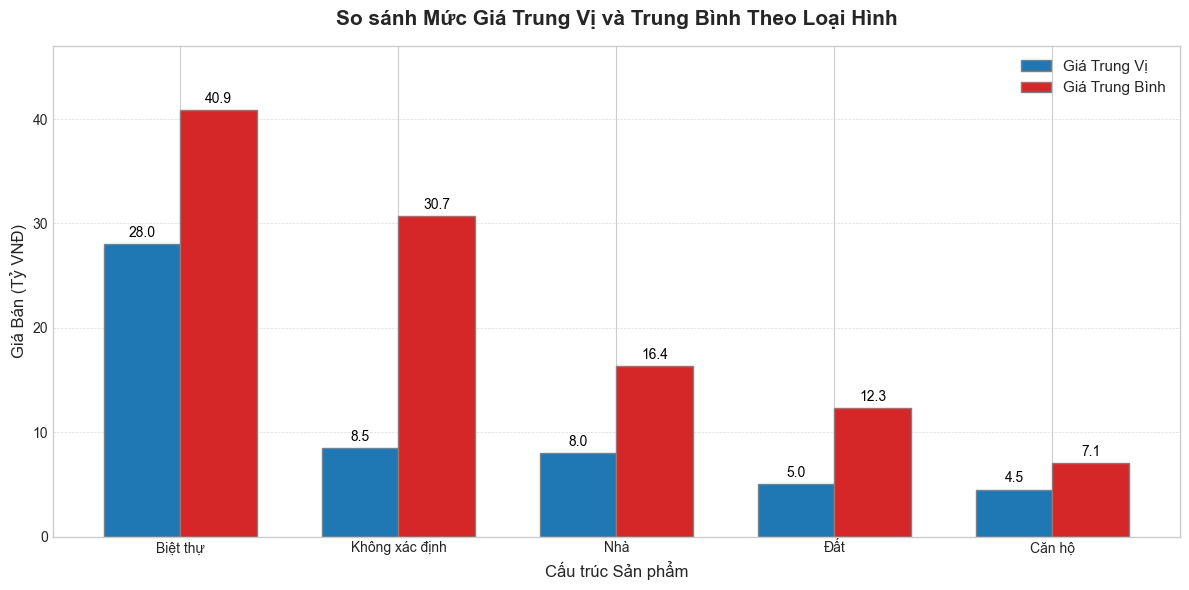

In [182]:
# 1. TÍNH TOÁN DỮ LIỆU CỐT LÕI (Bạn bị thiếu khúc này nè)
gia_theo_loai = df_eda[df_eda['Gia'] > 0].groupby('LoaiBDS').agg(
    So_luong=('Gia', 'count'),
    Gia_TB=('Gia', 'mean'),
    Gia_TrungVi=('Gia', 'median'),
    Gia_STD=('Gia', 'std')
).sort_values('Gia_TrungVi', ascending=False)

# Ép đưa về hệ tỷ VNĐ
gia_theo_loai['Gia_TrungVi_ty'] = gia_theo_loai['Gia_TrungVi'] / 1e9
gia_theo_loai['Gia_TB_ty'] = gia_theo_loai['Gia_TB'] / 1e9

# 2. VẼ BIỂU ĐỒ TRỰC QUAN HÓA
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12, 6))

x = np.arange(len(gia_theo_loai))
bar_width = 0.35

# Xanh hiền hòa cho Trung vị (Sự thật), Đỏ rực báo động cho Trung bình (Ảo giác)
bars_median = plt.bar(x - bar_width/2, gia_theo_loai['Gia_TrungVi_ty'], 
        width=bar_width, label='Giá Trung Vị', color='#1f77b4', edgecolor='gray')
bars_mean = plt.bar(x + bar_width/2, gia_theo_loai['Gia_TB_ty'], 
        width=bar_width, label='Giá Trung Bình', color='#d62728', edgecolor='gray')

# Gắn nhãn số tự động bằng bar_label của Matplotlib
ax = plt.gca()
ax.bar_label(bars_median, padding=3, fmt='{:.1f}', fontsize=10, color='black')
ax.bar_label(bars_mean, padding=3, fmt='{:.1f}', fontsize=10, color='black')

# Đặt nhãn trung tính chuẩn mực
plt.title('So sánh Mức Giá Trung Vị và Trung Bình Theo Loại Hình', fontsize=15, weight='bold', pad=15)
plt.ylabel('Giá Bán (Tỷ VNĐ)', fontsize=12)
plt.xlabel('Cấu trúc Sản phẩm', fontsize=12)

# Index ngắn nên để ngang đọc cho lẹ
plt.xticks(x, gia_theo_loai.index, rotation=0) 

# Đẩy trần Y lên 15% để số liệu trên cùng không bị cấn viền
plt.ylim(0, max(gia_theo_loai['Gia_TB_ty']) * 1.15)

plt.legend(fontsize=11)
plt.grid(True, axis='y', ls="--", linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.show()


Nhận xét: 

* **Ảo giác Cột Đỏ:** Tương tự như bảng Quận, cột Giá Trung Bình (Đỏ) luôn nhỉnh hơn vọt xà so với Giá Trung Vị (Xanh) ở BẤT KỲ loại hình nào. Tức là thị trường BĐS Sài Gòn luôn bị chi phối lệch phải nặng nề bởi thiểu số các căn nhà giá cực cao.

* **Biệt thự - Chảo lửa phân hóa:** Mức chênh lệch khủng khiếp nhất xảy ra ở nhóm Biệt thự (Cột Đỏ chót vót >41 Tỷ trong khi Xanh chỉ 27 Tỷ). Nhóm này là nơi tụ họp của các siêu dinh thự hàng trăm tỷ thao túng thị trường.

* **Căn hộ** giữ được chênh lệch của 2 cột ở con số thấp nhất (4.5 vs ~7 Tỷ). Khẳng định: Nguồn cung căn hộ phân bổ rất đầm, biên độ hẹp, tính chuẩn hóa cao

### **6.4 Phân tích tỷ lệ LoaiBDS trong từng QuanHuyen (Top 5 quận phổ biến nhất)**

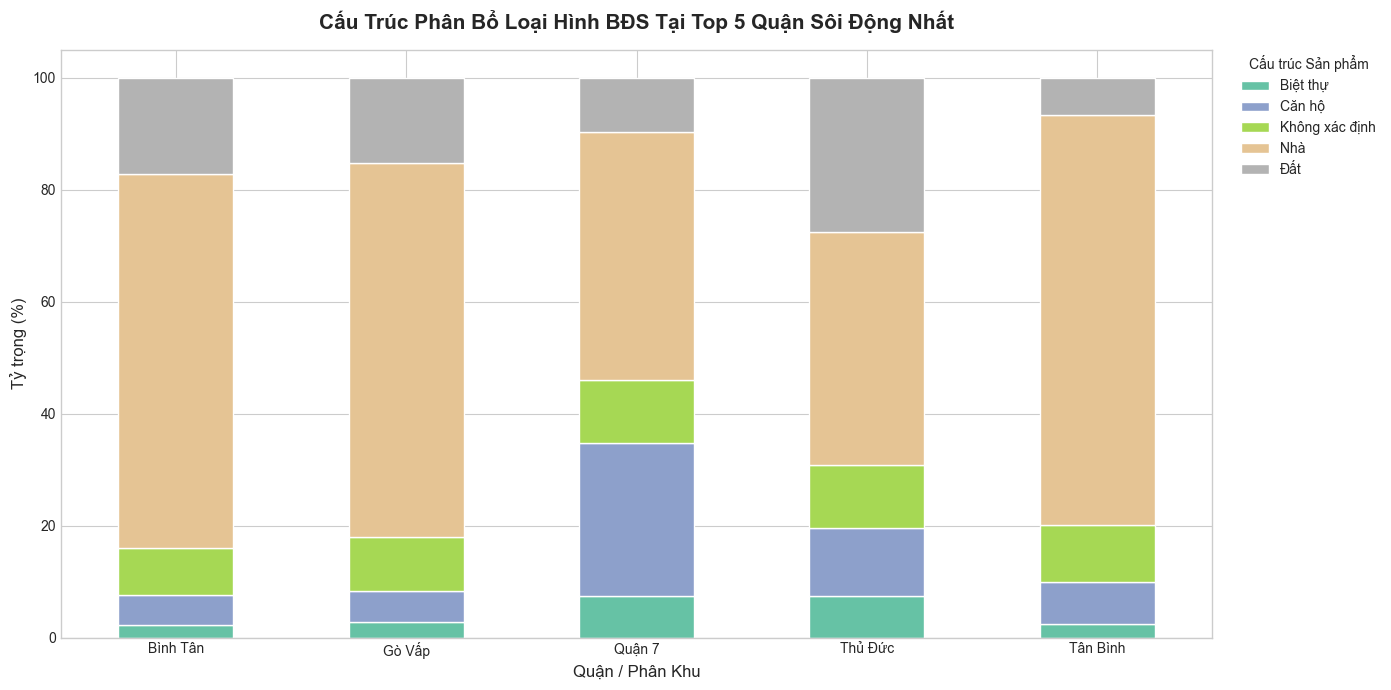

In [183]:
# 1. Lọc Top 5 Quận sôi động nhất
top_5_quan = df_eda['QuanHuyen'].value_counts().head(5).index
df_top5_quan = df_eda[df_eda['QuanHuyen'].isin(top_5_quan)]

# 2. Tạo bảng Crosstab tỷ lệ phần trăm (Nhân 100 để ra hệ %)
cross_tab_percent = pd.crosstab(df_top5_quan['QuanHuyen'], df_top5_quan['LoaiBDS'], normalize='index') * 100

# 3. Vẽ biểu đồ Stacked Bar
ax = cross_tab_percent.plot(
    kind='bar', stacked=True, figsize=(14, 7), 
    cmap='Set2', edgecolor='white' # Màu Set2 pastel thanh lịch, viền trắng mượt mà
)

plt.title('Cấu Trúc Phân Bổ Loại Hình BĐS Tại Top 5 Quận Sôi Động Nhất', fontsize=15, weight='bold', pad=15)
plt.xlabel('Quận / Phân Khu', fontsize=12)
plt.ylabel('Tỷ trọng (%)', fontsize=12)
plt.xticks(rotation=0)

plt.legend(title='Cấu trúc Sản phẩm', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()


* Nhận xét
    * Nhà chiếm da số hầu hết Top 5 quận
    * Đất có tỷ trọng cao ở Thủ Đức
    * Căn hộ nổi bậc nhất ở Quận 7 
    * Không xác định chiến khoảng 8 ~ 11%

## **7. Phân tích theo thời gian**

### **7.1 Khởi tạo dữ liệu Chuỗi thời gian**

In [184]:
# 1. Ép kiểu Ngày tháng năm về quy mô Tháng/Năm 
df_eda['NamThang'] = df_eda['NgayDang'].dt.to_period('M')

# Nhóm dồn dữ liệu theo Tháng để đo lường
time_stats = df_eda.groupby('NamThang').agg(
    SoLuongTin=('Gia', 'count'),
    GiaTrungVi=('Gia', 'median'),        # Đo lường tổng tiền
    GiaM2TrungVi=('Gia_m2', 'median')    # Đo lường sức nóng lõi của Đất
).reset_index()

# 2. Xử lý "dọn rác" số liệu khoa học (1.25e+9): Quy đổi Tỷ / Triệu
time_stats['GiaTrungVi_ty'] = (time_stats['GiaTrungVi'] / 1e9).round(5)
time_stats['GiaM2TrungVi_trieu'] = (time_stats['GiaM2TrungVi'] / 1e6).round(5)

# 3. Ép Timestamp để vẽ biểu đồ Line Chart không bị lỗi gãy dải chữ X
time_stats['NamThang'] = time_stats['NamThang'].dt.to_timestamp()

print("Khởi tạo Chuỗi thời gian (Hiển thị 12 Tháng đầu tiên)")
display(time_stats[['NamThang', 'SoLuongTin', 'GiaTrungVi_ty', 'GiaM2TrungVi_trieu']].head(12))


Khởi tạo Chuỗi thời gian (Hiển thị 12 Tháng đầu tiên)


,NamThang,SoLuongTin,GiaTrungVi_ty,GiaM2TrungVi_trieu
0,2021-04-01,11,1,10
1,2021-05-01,301,4,65
2,2021-06-01,548,4,74
3,2021-07-01,293,5,74
4,2021-08-01,309,6,85
5,2022-05-01,387,3,34
6,2022-06-01,968,6,80
7,2022-07-01,1281,4,48
8,2022-08-01,849,4,60
9,2022-09-01,982,4,51


### **7.2 Trực quan hóa: Số lượng tin đăng theo thời gian**

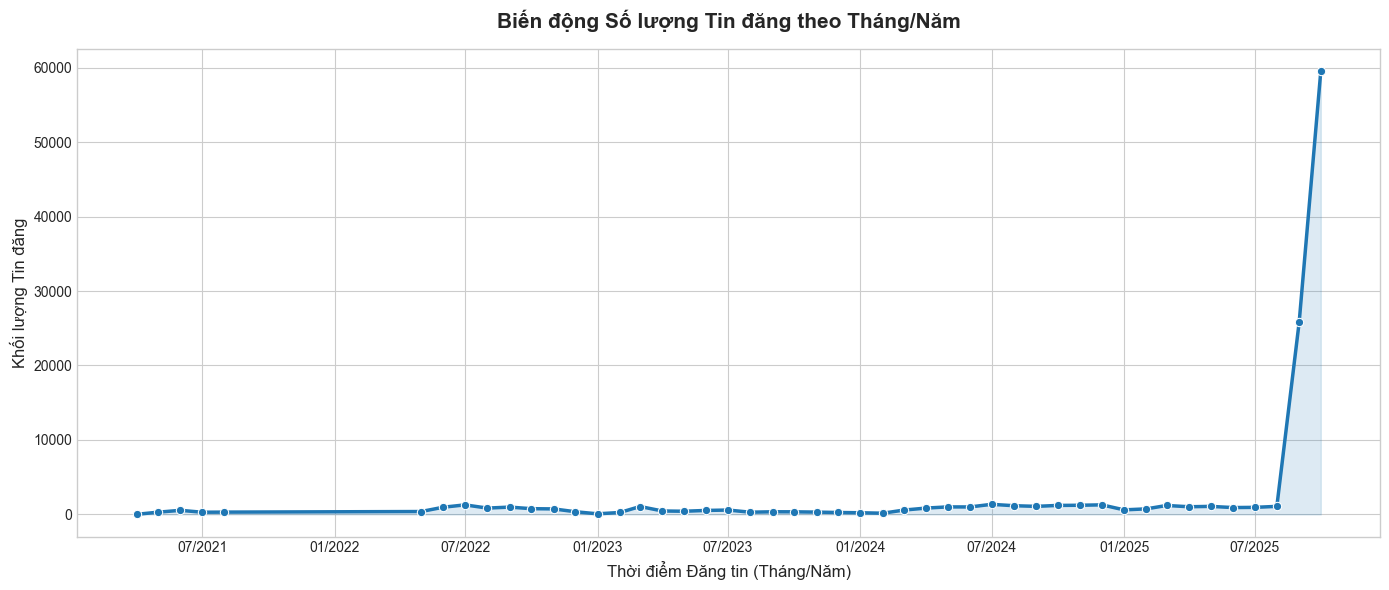

In [185]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(14, 6))

# Vẽ Area Plot đầm và chắc chắn
ax = sns.lineplot(
    data=time_stats, x='NamThang', y='SoLuongTin', 
    marker='o', markersize=6, linewidth=2.5, color='#1f77b4'
)
plt.fill_between(time_stats['NamThang'], time_stats['SoLuongTin'], color='#1f77b4', alpha=0.15)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))

plt.title('Biến động Số lượng Tin đăng theo Tháng/Năm', fontsize=15, weight='bold', pad=15)
plt.xlabel('Thời điểm Đăng tin (Tháng/Năm)', fontsize=12)
plt.ylabel('Khối lượng Tin đăng', fontsize=12)

plt.tight_layout()
plt.show()


**Nhận xét**
- **Độ nhiễu cực đoan:** Khối lượng tin đăng gần như đi ngang tiệm cận 0 từ 2021-2024, nhưng lại vọt xà thẳng đứng lên mốc 60.000 tin vào cuối 2025.
- **Bản chất (Data Bias):** Sự tăng vọt phi logic này phản ánh "Thời điểm Crawl dữ liệu" (các tin cũ đã bị sàn BĐS gỡ/xóa hết, tin mới thì được cập nhật liên tục), chứ không mang ý nghĩa bùng nổ nguồn cung thực tế của thị trường.



### **7.3 Trực quan hóa: Tổng giá (Gia) trung vị theo thời gian**

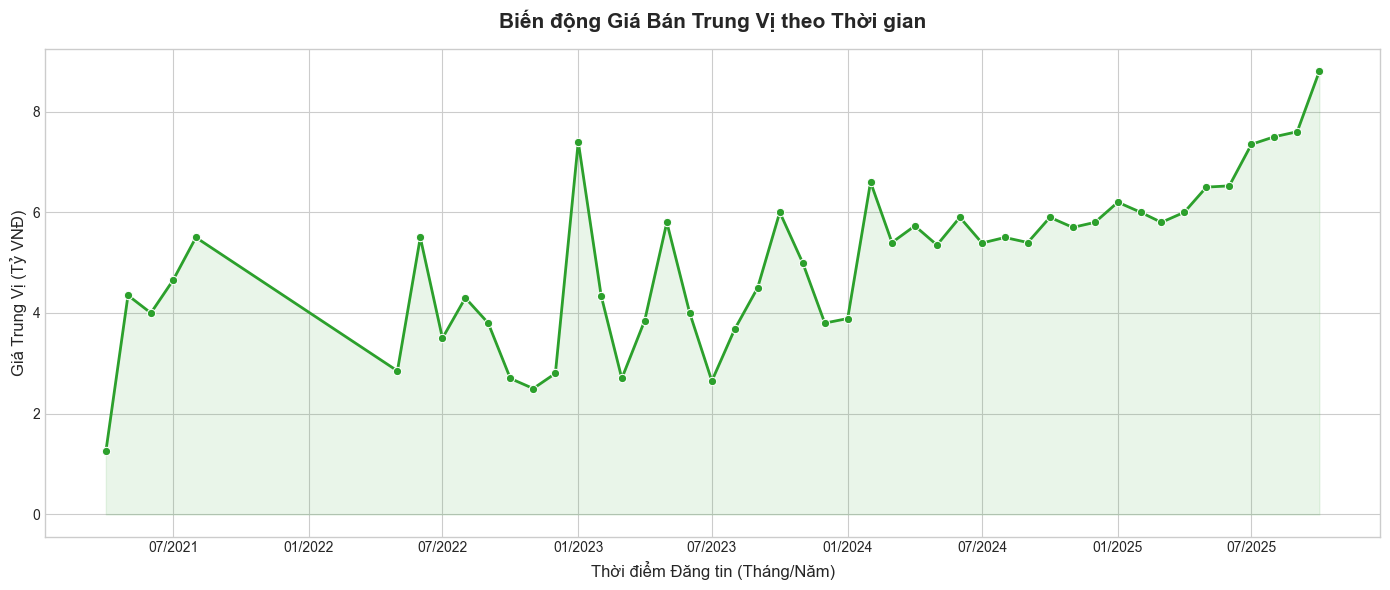

In [186]:
if not time_stats.empty:
    plt.figure(figsize=(14, 6))
    
    # Chuyển sang màu Xanh lá (Green), xài hệ Tỷ đễ trục Y sạch sẽ số liệu
    ax = sns.lineplot(
        data=time_stats, x='NamThang', y='GiaTrungVi_ty', 
        marker='o', markersize=6, linewidth=2, color='#2ca02c' 
    )
    plt.fill_between(time_stats['NamThang'], time_stats['GiaTrungVi_ty'], color='#2ca02c', alpha=0.1)

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))

    plt.title('Biến động Giá Bán Trung Vị theo Thời gian', fontsize=15, weight='bold', pad=15)
    plt.xlabel('Thời điểm Đăng tin (Tháng/Năm)', fontsize=12)
    plt.ylabel('Giá Trung Vị (Tỷ VNĐ)', fontsize=12)
    
    plt.tight_layout()
    plt.show()
else:
    print("Không có dữ liệu 'time_stats' để vẽ biểu đồ.")


**Nhận xét (Biến động Giá Bán Trung Vị):**
- **Nửa đầu nhiễu loạn (2021-2023):** Quỹ đạo giá dích dắc giật cục (từ 2 Tỷ vọt lên 7.5 Tỷ). Nguyên nhân: Lượng mẫu data quá ít, trung vị dễ bị thao túng bởi rác tin ảo hoặc môt phà biệt thự khủng.
- **Nửa sau ổn định (2024-2025):** Khi mật độ dữ liệu đủ dày (lượng tin đăng nhiều), đường giá đi mượt lại và phác họa xu hướng tăng trưởng đều đặn (từ sàn 5 Tỷ tiến về đỉnh gần 9 Tỷ cuối năm 2025).



### **7.4 Trực quan hóa: Đơn giá (Gia_m2) trung vị theo thời gian**

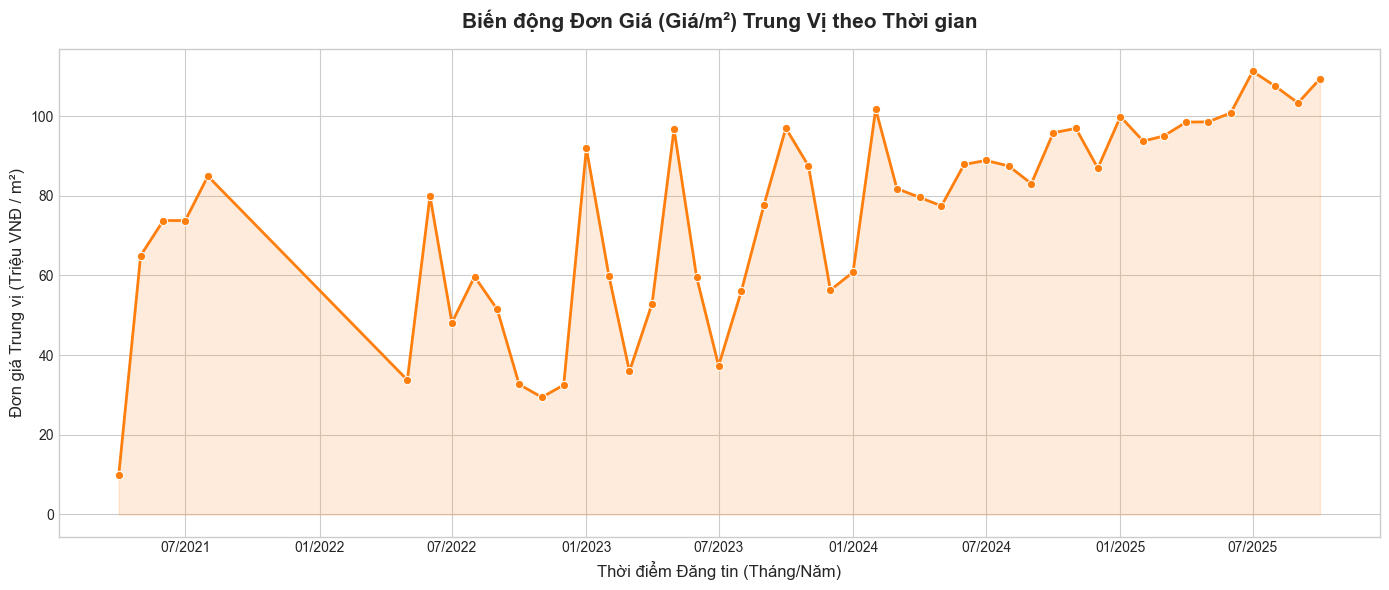

In [187]:
if not time_stats.empty:
    plt.figure(figsize=(14, 6))
    
    ax = sns.lineplot(
        data=time_stats, x='NamThang', y='GiaM2TrungVi_trieu', 
        marker='o', markersize=6, linewidth=2, color='#ff7f0e' # Đổi sang màu Cam 
    )
    plt.fill_between(time_stats['NamThang'], time_stats['GiaM2TrungVi_trieu'], color='#ff7f0e', alpha=0.15)

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))

    plt.title('Biến động Đơn Giá (Giá/m²) Trung Vị theo Thời gian', fontsize=15, weight='bold', pad=15)
    plt.xlabel('Thời điểm Đăng tin (Tháng/Năm)', fontsize=12)
    plt.ylabel('Đơn giá Trung vị (Triệu VNĐ / m²)', fontsize=12)
    
    plt.tight_layout()
    plt.show()
else:
    print("Không có dữ liệu 'time_stats' để vẽ biểu đồ.")


**Nhận xét (Biến động Đơn giá Giá/m²):**
- **Đồng pha hệ thống:** Đồ thị Đơn giá (Giá/m²) sao chép y hệt quỹ đạo của đồ thị Tổng giá. Sự hỗn loạn giật cục (tăng vọt/rơi tự do) ở giai đoạn 2021-2023 khẳng định lại vấn đề "Thiếu hụt dữ liệu gốc", chứ không phải do sự đột biến ngẫu nhiên của thị trường.
- **Xác lập mặt bằng mới:** Khi mật độ tin đăng dày đặc vào năm 2025, đường đơn giá dốc dần và tiệm cận mốc 110 Triệu/m²

